# Regression Tree AVM — Malaysian Residential Property Valuation

## 1. Regression Tree AVM Objective

This notebook builds an **interpretable single-tree baseline** (`sklearn.tree.DecisionTreeRegressor`) for estimating Malaysian residential property valuations from property attributes and location — the fourth entry in this project's model-selection comparison (OLS → Random Forest → XGBoost → **Regression Tree**).

**This is explicitly *not* meant to be the best model.** A lone Regression Tree is a high-variance, overfitting-prone learner — the point of building it is to test, honestly, whether a single transparent tree can produce *useful valuation logic* on its own, and to provide a fully-interpretable reference point against which the ensembles (Random Forest, XGBoost) can be judged. If it overfits badly (which is the expected, textbook behaviour for an unconstrained tree), that is itself the finding — not a failure to hide.

**What this notebook will do, in order:**
1. Inspect the dataset and confirm column names, target, missingness, and cardinality — fresh, not assumed from prior notebooks.
2. Build a leakage-safe preprocessing pipeline (shared in spirit with `randomForest.ipynb` / `xgBoost.ipynb`, but re-verified here).
3. Run a **measured** two-scenario experiment on `Road Name` — both prior notebooks dropped it, but this notebook will test it for itself on a single tree, which behaves very differently from an ensemble, and let the 2026 holdout decide.
4. Train an unconstrained baseline tree, diagnose its overfitting honestly, then prune/tune it with a chronologically-correct validation protocol (train `Year<2025` / validate `Year==2025`).
5. Compare the result — on the *same* held-out 2026 test set — against the Random Forest and XGBoost benchmarks already built in this project.
6. Build a deployable prediction function with an honest, residual-based valuation **range** (not a single point estimate).

**Chronological evaluation discipline (applies throughout this notebook):**
- **Train**: `Year < 2025` — the only data the model ever learns from.
- **Validation**: `Year == 2025` — used for diagnosis, tuning, and **valuation-range calibration**. Never used for final reporting.
- **Test**: `Year == 2026` — touched only for final, one-shot, unbiased evaluation. Never used to calibrate anything.

This mirrors the protocol used in `randomForest.ipynb` and `xgBoost.ipynb` so that the final comparison table (Section 13) is a genuine apples-to-apples evaluation, not three different experiments dressed up as one.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, median_absolute_error
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

print('Libraries loaded.')


Libraries loaded.


## 2. Dataset Inspection

Loading the cleaned dataset and confirming its shape, column names, dtypes, and a sample of rows — before assuming anything about structure (this is the same file used by `randomForest.ipynb` and `xgBoost.ipynb`, but every number in this notebook is recomputed from scratch).


In [2]:
import os

DATA_PATH = '../processed data/Open Transaction Data Cleaned.xlsx'
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f'Data file not found: {DATA_PATH}')

df = pd.read_excel(DATA_PATH)

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print()
print('Columns and dtypes:')
print(df.dtypes)
print()
df.head(8)


Shape: 416,627 rows x 13 columns

Columns and dtypes:
Property Type                  str
District                       str
Mukim                       object
Scheme Name/Area               str
Road Name                   object
Transaction Date    datetime64[us]
Tenure                         str
Land                       float64
Area                       float64
Unit Level                  object
Price                        int64
Year                         int64
Month                        int64
dtype: object



,Property Type,District,Mukim,Scheme Name/Area,Road Name,Transaction Date,Tenure,Land,Area,Unit Level,Price,Year,Month
0,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Bdr Masjid Tanah,TMN BUKIT INDAH FASA 2,JLN BUKIT INDAH 6,2024-03-01,Freehold,374.0,106.0,,470000,2024,3
1,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN BELIMBING HARMONI,JLN BELIMBING HARMONI,2023-05-01,Leasehold,234.0,67.0,,483000,2023,5
2,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,2021-04-01,Freehold,268.0,118.0,,359000,2021,4
3,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,2021-04-01,Freehold,268.0,118.0,,435000,2021,4
4,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,2021-04-01,Freehold,297.0,118.0,,373000,2021,4
5,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,2021-05-01,Freehold,268.0,118.0,,435000,2021,5
6,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,2021-05-01,Freehold,268.0,118.0,,658000,2021,5
7,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,2021-05-01,Freehold,297.0,118.0,,458000,2021,5


## 3. Feature and Target Selection

**Target**: the dataset already contains a clean `Price` column (int64, RM, no `Transaction Price (RM)` renaming needed) — confirming this as the regression target.

**Candidate predictors** (everything except the target and temporal/derived columns):
`Property Type`, `District`, `Mukim`, `Scheme Name/Area`, `Road Name`, `Tenure`, `Land`, `Area`, `Unit Level`

**Excluded from the model input**, per the brief's modelling decisions:
- `Unit Level` — too micro/unit-specific; mostly meaningless for landed properties (the majority of this dataset's 11 property types)
- `Year`, `Month`, `Transaction Date` — would let the model take a market-timing/seasonality shortcut instead of learning genuine valuation relationships from property attributes (full justification in Section 5)
- `Price` is obviously the target, not a feature

**`Road Name` is deliberately left as an open question here** — both `randomForest.ipynb` and `xgBoost.ipynb` excluded it, but on different grounds (RF: a-priori cardinality reasoning; XGBoost: a measured two-scenario test). This notebook will run its **own** measured experiment in Section 8 and let the 2026 holdout — not the other notebooks' conclusions — decide whether it survives into the final feature set for a *single* tree (which has no ensembling to average out a noisy field).

So the **candidate base feature set** going into preprocessing is:
`['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Tenure', 'Land', 'Area']`, with `Road Name` tested as an optional 8th feature in Section 8.


Target column: "Price"  dtype=int64  missing=0
Price range: RM 5,000 - RM 38,000,000
Price median: RM 371,000   mean: RM 499,460

Skewness of raw Price      : 9.79
Skewness of log1p(Price)   : 0.14


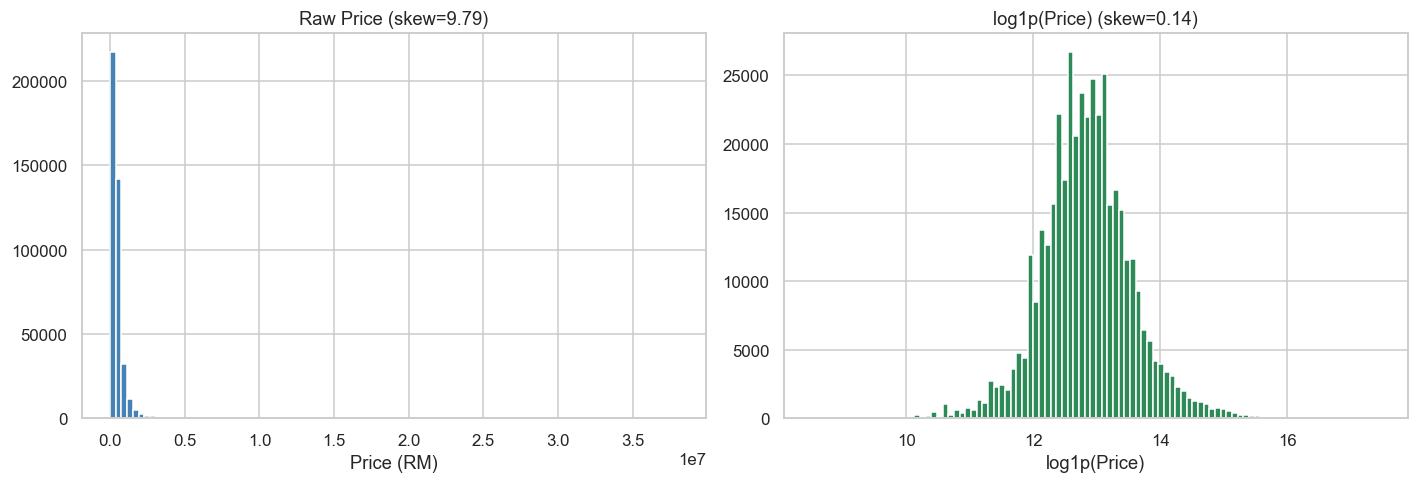

In [3]:
FEATURES = ['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Tenure', 'Land', 'Area']
TARGET = 'Price'

print(f'Target column: "{TARGET}"  dtype={df[TARGET].dtype}  missing={df[TARGET].isna().sum()}')
print(f'Price range: RM {df[TARGET].min():,} - RM {df[TARGET].max():,}')
print(f'Price median: RM {df[TARGET].median():,.0f}   mean: RM {df[TARGET].mean():,.0f}')
print()

raw_skew = df[TARGET].skew()
log_skew = np.log1p(df[TARGET]).skew()
print(f'Skewness of raw Price      : {raw_skew:.2f}')
print(f'Skewness of log1p(Price)   : {log_skew:.2f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(df[TARGET], bins=100, color='steelblue')
axes[0].set_title(f'Raw Price (skew={raw_skew:.2f})')
axes[0].set_xlabel('Price (RM)')
axes[1].hist(np.log1p(df[TARGET]), bins=100, color='seagreen')
axes[1].set_title(f'log1p(Price) (skew={log_skew:.2f})')
axes[1].set_xlabel('log1p(Price)')
plt.tight_layout()
plt.show()


## 4. Missing Value and Cardinality Inspection

### 4.1 Missing values

Checking every candidate feature plus `Road Name` for missingness — and, since `Area` is suspected of structural (not random) missingness, breaking it down **by `Property Type`** to see exactly which types are affected and by how much. (Per the user's correction: this is recomputed fresh here, not assumed from the Random Forest notebook's findings.)


In [4]:
inspect_cols = FEATURES + ['Road Name', 'Unit Level']
miss = df[inspect_cols].isna().sum().to_frame('missing_count')
miss['missing_pct'] = (miss['missing_count'] / len(df) * 100).round(2)
print('Missing values (full dataset):')
print(miss)
print()

# Area missingness broken down by Property Type -- computed fresh, no assumptions
area_missing_by_type = (
    df.assign(area_missing=df['Area'].isna())
      .groupby('Property Type')['area_missing']
      .agg(['sum', 'count'])
      .rename(columns={'sum': 'missing', 'count': 'total'})
)
area_missing_by_type['missing_pct'] = (area_missing_by_type['missing'] / area_missing_by_type['total'] * 100).round(2)
area_missing_by_type = area_missing_by_type.sort_values('missing_pct', ascending=False)
print('Area missingness by Property Type:')
print(area_missing_by_type)

fully_missing_types = area_missing_by_type.index[area_missing_by_type['missing_pct'] == 100.0].tolist()
fully_present_types = area_missing_by_type.index[area_missing_by_type['missing_pct'] == 0.0].tolist()
print()
print(f'Property Types with Area 100% missing : {fully_missing_types}')
print(f'Property Types with Area 0% missing   : {fully_present_types}')


Missing values (full dataset):
                  missing_count  missing_pct
Property Type                 0         0.00
District                      0         0.00
Mukim                         0         0.00
Scheme Name/Area              0         0.00
Tenure                        0         0.00
Land                          1         0.00
Area                     107740        25.86
Road Name                     2         0.00
Unit Level                    0         0.00

Area missingness by Property Type:
                                missing   total  missing_pct
Property Type                                               
Low-Cost Flat                     21190   21190       100.00
Town House                         4251    4251       100.00
Condominium/Apartment             65780   65780       100.00
Flat                              16504   16504       100.00
2 - 2 1/2 Storey Semi-Detached        2   18071         0.01
1 - 1 1/2 Storey Semi-Detached        3   22030         

**Findings — Area missingness is structural, not random:**

`Area` is missing for 25.86% of rows overall, but the breakdown by `Property Type` shows this is *exactly* a property-type-driven pattern, not random noise:
- **Exactly 100% missing** for `Low-Cost Flat`, `Town House`, `Condominium/Apartment`, `Flat` — all four are strata/high-rise types where "floor area" is presumably either not collected or not transacted the same way in the source data
- **Effectively 0% missing** (0.00–0.01%, i.e. a handful of rows) for the landed types (`Terraced`, `Semi-Detached`, `Detached`, `Cluster House`, `Low-Cost House`)

This means a flat global median imputation would systematically distort the strata types (assigning them a landed-property's typical floor area), while a **per-`Property Type` median imputer** preserves the genuine signal for the landed types and degrades gracefully (falls back to a global median) for the four types that have *no* signal to learn from at all. `Land` has a single missing value (simple median imputation is sufficient) and `Road Name` has 2 missing values — both negligible.

### 4.2 Categorical feature cardinality

For the high-cardinality location fields (`Mukim`, `Scheme Name/Area`, `Road Name`), the deciding question for deployment usefulness is not "how many unique values exist" but **"what fraction of 2026 categories were never seen during training"** — that is the rate at which a deployed model would have to fall back on a default/zero encoding for a real user input.


In [5]:
cat_cols = ['Property Type', 'District', 'Tenure', 'Mukim', 'Scheme Name/Area', 'Road Name']

train_mask_preview = df['Year'] < 2025
test_mask_preview = df['Year'] == 2026

card_rows = []
for col in cat_cols:
    n_unique = df[col].nunique(dropna=True)
    train_cats = set(df.loc[train_mask_preview, col].dropna().unique())
    test_cats = df.loc[test_mask_preview, col].dropna()
    unseen_rate = (~test_cats.isin(train_cats)).mean() * 100
    card_rows.append({'Feature': col, 'Unique values (full data)': n_unique,
                      '2026 unseen rate (%)': round(unseen_rate, 2)})

card_df = pd.DataFrame(card_rows)
print(card_df.to_string(index=False))
print()
print(f'Train rows (Year<2025): {train_mask_preview.sum():,}   Test rows (Year==2026): {test_mask_preview.sum():,}')

# Frequency profile of Road Name -- is it really mostly near-singletons?
road_counts = df.loc[train_mask_preview, 'Road Name'].value_counts()
print()
print(f'Road Name -- median training frequency: {road_counts.median():.0f}   '
      f'share of road names appearing <=3 times: {(road_counts <= 3).mean()*100:.1f}%')


         Feature  Unique values (full data)  2026 unseen rate (%)
   Property Type                         11                  0.00
        District                        127                  0.14
          Tenure                          2                  0.00
           Mukim                       1343                  1.78
Scheme Name/Area                      23718                 10.18
       Road Name                     121825                 35.13

Train rows (Year<2025): 375,800   Test rows (Year==2026): 5,668

Road Name -- median training frequency: 1   share of road names appearing <=3 times: 86.1%


**Findings — encoding strategy by cardinality:**

| Feature | Unique values | 2026 unseen rate | Encoding decision |
|---|---:|---:|---|
| `Property Type` | 11 | 0.00% | `OneHotEncoder(handle_unknown="ignore")` — tiny, stable vocabulary |
| `Tenure` | 2 | 0.00% | `OneHotEncoder(handle_unknown="ignore")` |
| `District` | 127 | 0.14% | `OneHotEncoder(handle_unknown="ignore")` — manageable width, near-zero unseen risk |
| `Mukim` | 1,343 | 1.78% | **Frequency encoding** — too wide for one-hot, low unseen risk, genuinely informative sub-district signal |
| `Scheme Name/Area` | 23,718 | 10.18% | **Frequency encoding** — one-hot would explode the column space; frequency keeps it compact and safe for unseen schemes (→ 0) |
| `Road Name` | 121,825 | **35.13%** | **Open question — tested empirically in Section 8**, not decided here |

`Road Name`'s numbers are stark on their face — over a third of 2026 road names were never seen in training, and the median training frequency of a road name is **1** (86.1% of road names appear 3 times or fewer). That is the textbook profile of a field a model can only memorise, not generalise from. **But** "looks like noise" and "measurably acts like noise for *this* model" are different claims — Section 8 will fit the actual tree both ways and let the held-out 2026 set decide, exactly as the user asked, rather than carrying RF's/XGBoost's verdicts over by assumption.

## 5. `Unit Level`, `Year`, and `Month` Exclusion Justification

**`Unit Level` is dropped** because it is too micro/unit-specific to generalise across an 11-type catalogue that is mostly landed housing. A "Level 12" unit only means something for high-rise strata types (`Condominium/Apartment`, `Flat`, `Low-Cost Flat`, `Town House` — exactly the same four types that have *no* `Area` data at all, per Section 4.1) — for the remaining 7 landed types the field is essentially meaningless or constant. Including it risks the tree carving spurious splits on a field that is only locally informative, which would hurt generalisability and deployment-friendliness (a user describing a terraced house has no sensible "Unit Level" to enter at all).

**`Year` and `Month` are dropped from the model's *input features*** (while `Year` is kept purely as the chronological split key):
- **`Year`**: if the model could see `Year`, it would learn "prices go up over time" as a trivial shortcut rather than learning genuine valuation relationships from property attributes and location. Worse, it would make the chronological train/test split nearly meaningless — the model would just be interpolating a trend line it was handed directly, not demonstrating that it can value a property from its *characteristics*.
- **`Month`**: would let the tree fit historical transaction-seasonality quirks (e.g. "March 2021 was unusually hot") that are an artefact of *when* past sales happened to register, not durable properties of *what* a property is worth. A deployable AVM should value a property the same way regardless of which month a user happens to be asking in.

**Honest cost of this decision** (carried through the rest of the notebook): because `Year`/`Month` are excluded, this model **cannot** learn market-wide appreciation or seasonal drift. Any real difference between pre-2025 and 2026 price levels will surface as **systematic bias** in the 2026 test results (Section 9), not as something the model "knew about" — that is the price paid for keeping the model honestly focused on deployable, property-level inputs rather than a historical-trend shortcut.


## 6. Preprocessing Strategy

Everything below is wrapped in a single pipeline-safe `ColumnTransformer` + `Pipeline`, fit **only on training data** (`Year < 2025`), so validation, test, and any future live user input pass through *exactly* the same transformation with no leakage:

- **`Property Type`, `Tenure`, `District`** — `OneHotEncoder(handle_unknown="ignore")`. All three are low-cardinality with near-zero unseen rates (Section 4.2); unknown categories at inference safely become an all-zero row rather than raising an error.
- **`Mukim`, `Scheme Name/Area`** — a custom `FrequencyEncoder` (category → its training-set transaction count; unseen category → 0). Keeps the encoded width compact (no 1,343- or 23,718-column explosion) while preserving genuine "how common is this location" signal, and degrades safely for unseen locations.
- **`Land`** — `SimpleImputer(strategy="median")`. Only 1 missing value in the entire dataset; trivial.
- **`Area`** — a custom `PropertyTypeMedianImputer`. Section 4.1 showed `Area` missingness is *structural*, not random (exactly 100% missing for 4 strata types, ~0% for landed types), so a flat median would force a landed-property floor area onto every strata-type row. The imputer instead:
  1. uses the **training-set median `Area` for that row's `Property Type`**, where that type has any valid `Area` values;
  2. falls back to the **global training-set median `Area`** for a `Property Type` that has *no* valid `Area` values at all (the four 100%-missing strata types — there is no type-level signal to use, so this is the honest fallback, not a workaround);
  3. at inference, falls back to the same global median for a `Property Type` the imputer has never seen in training.

Both custom transformers are scikit-learn-compatible (`BaseEstimator`, `TransformerMixin`) and are **fit only on the training fold** — the same leakage-safe contract used in `randomForest.ipynb` / `xgBoost.ipynb`.


In [6]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    """Maps a category to its training-set transaction count. Unseen categories -> 0.
    Fit only on the training fold -- no leakage from validation/test/live input."""

    def fit(self, X, y=None):
        self.freq_map_ = pd.Series(np.asarray(X).ravel().astype(str)).value_counts().to_dict()
        return self

    def transform(self, X):
        return (pd.Series(np.asarray(X).ravel().astype(str))
                  .map(self.freq_map_)
                  .fillna(0)
                  .to_numpy(dtype=float)
                  .reshape(-1, 1))

    def get_feature_names_out(self, input_features=None):
        # Single input column -> single output column; keep the original name
        # so prep.get_feature_names_out() (used in Sections 14-17) is meaningful.
        return np.asarray(input_features, dtype=object)


LANDED_TYPES = {
    "1 - 1 1/2 Storey Semi-Detached",
    "1 - 1 1/2 Storey Terraced",
    "2 - 2 1/2 Storey Semi-Detached",
    "2 - 2 1/2 Storey Terraced",
    "Cluster House",
}


class AreaImputer(BaseEstimator, TransformerMixin):
    """Imputes 'Area' (Main Floor Area) respecting structural non-applicability.

    - Landed property types: missing Area is an ordinary missing value, filled
      with the per-type training median (fallback: overall landed training median).
    - Non-landed/high-rise property types: Area is structurally not applicable
      (recorded as '-'/empty in the source data), so it is filled with a sentinel
      0 instead of a fabricated median -- imputing a median here would invent a
      private floor area for property types that never had one recorded.
    Input: 2 columns [Area, Property Type] -> Output: 1 imputed numeric column."""

    def fit(self, X, y=None):
        area = pd.to_numeric(pd.Series(np.asarray(X)[:, 0]), errors='coerce')
        ptype = pd.Series(np.asarray(X)[:, 1].astype(str))
        landed_mask = ptype.isin(LANDED_TYPES)
        landed_area = area[landed_mask]
        self.global_landed_median_ = float(landed_area.median())
        self.type_medians_ = landed_area.groupby(ptype[landed_mask]).median().dropna().to_dict()
        return self

    def transform(self, X):
        area = pd.to_numeric(pd.Series(np.asarray(X)[:, 0]), errors='coerce')
        ptype = pd.Series(np.asarray(X)[:, 1].astype(str))
        landed_mask = ptype.isin(LANDED_TYPES)

        filled = area.copy()
        landed_missing = landed_mask & area.isna()
        if landed_missing.any():
            fill_values = ptype[landed_missing].map(
                lambda t: self.type_medians_.get(t, self.global_landed_median_)
            ).astype(float)
            filled.loc[landed_missing] = fill_values.values
        filled.loc[~landed_mask] = 0.0
        return filled.to_numpy(dtype=float).reshape(-1, 1)

    def get_feature_names_out(self, input_features=None):
        # [Area, Property Type] -> single imputed Area column
        return np.array(['Area'], dtype=object)


def build_tree_pipeline(feature_cols, freq_cols, tree_params=None):
    """Builds a leakage-safe ColumnTransformer + DecisionTreeRegressor pipeline.

    feature_cols : full list of feature columns the pipeline will select from X
    freq_cols    : subset of feature_cols to frequency-encode (e.g. Mukim, Scheme Name/Area,
                   and -- in the Road Name experiment scenario -- Road Name too).
                   Each gets its OWN FrequencyEncoder instance/fit -- a single shared instance
                   would blend categories from different columns into one frequency map.
    """
    one_hot_cols = [c for c in ['Property Type', 'District', 'Tenure'] if c in feature_cols]

    transformers = [('one_hot', OneHotEncoder(handle_unknown='ignore'), one_hot_cols)]
    for col in freq_cols:
        safe_name = col.lower().replace(' ', '_').replace('/', '_')
        transformers.append((f'freq_{safe_name}', FrequencyEncoder(), [col]))
    transformers.append(('land', SimpleImputer(strategy='median'), ['Land']))
    transformers.append(('area', AreaImputer(), ['Area', 'Property Type']))

    preprocessor = ColumnTransformer(transformers=transformers)

    params = dict(random_state=42)
    if tree_params:
        params.update(tree_params)

    return Pipeline([('prep', preprocessor), ('tree', DecisionTreeRegressor(**params))])


print('Custom transformers and build_tree_pipeline() defined.')


Custom transformers and build_tree_pipeline() defined.


## 7. Chronological Train / Validation / Test Split Strategy

Per the brief, the split is **chronological by `Year`** — never random. An AVM is judged on whether it can value *future* transactions from *past* ones; a random split would let near-duplicate listings (same scheme, similar dates, similar prices) leak across the train/test boundary and produce an optimistic, false sense of accuracy.

- **Train**: `Year < 2025`
- **Validation** (diagnostic / tuning / range-calibration only — never the final number): `Year == 2025`
- **Test** (final, one-shot, untouched until evaluation): `Year == 2026`

Section 4.2 already confirmed the row counts (375,800 / 35,159 / 5,668) — the 2026 test set is large enough for a meaningful evaluation, so the brief's "stop and report" condition for an unusably small test set does not apply here.

`Price` is trained as `log1p(Price)` (Section 3 showed raw skew = 9.79 collapses to 0.14 in log space) and every reported metric is `expm1`-inverted back to RM before being judged — exactly the convention `randomForest.ipynb` and `xgBoost.ipynb` use, which is what makes the final comparison table (Section 13) a fair one.


In [7]:
train_mask = df['Year'] < 2025
val_mask = df['Year'] == 2025
test_mask = df['Year'] == 2026

train_df = df.loc[train_mask].reset_index(drop=True)
val_df = df.loc[val_mask].reset_index(drop=True)
test_df = df.loc[test_mask].reset_index(drop=True)

y_train = np.log1p(train_df[TARGET])
y_val = np.log1p(val_df[TARGET])
y_test = np.log1p(test_df[TARGET])

MEDIAN_PRICE_TRAIN = float(train_df[TARGET].median())  # train-only reference, no peeking at val/test

print(f'Train (Year<2025) : {len(train_df):>8,} rows  ({len(train_df)/len(df)*100:.1f}%)')
print(f'Val   (Year==2025): {len(val_df):>8,} rows  ({len(val_df)/len(df)*100:.1f}%)')
print(f'Test  (Year==2026): {len(test_df):>8,} rows  ({len(test_df)/len(df)*100:.1f}%)')
print()
print(f'Median training Price (reference for RMSE-as-%-of-median): RM {MEDIAN_PRICE_TRAIN:,.0f}')


def metrics_for(y_true_log, y_pred_log, median_price=MEDIAN_PRICE_TRAIN):
    """All RM-space metrics after expm1 back-transform; R2 reported in both log and RM space."""
    y_true_rm, y_pred_rm = np.expm1(y_true_log), np.expm1(y_pred_log)
    rmse = float(np.sqrt(mean_squared_error(y_true_rm, y_pred_rm)))
    return dict(
        r2_log=r2_score(y_true_log, y_pred_log),
        r2_rm=r2_score(y_true_rm, y_pred_rm),
        rmse=rmse,
        mae=float(mean_absolute_error(y_true_rm, y_pred_rm)),
        medae=float(median_absolute_error(y_true_rm, y_pred_rm)),
        rmse_pct=rmse / median_price * 100,
    )


def evaluate_pipeline(pipeline, label=''):
    """Fit-agnostic evaluation: predicts & scores Train/Val/Test, prints a formatted table,
    and returns (metrics_dict, predictions_dict) for downstream diagnosis/plots/comparison."""
    preds = {
        'Train': pipeline.predict(train_df[pipeline_features(pipeline)]),
        'Val': pipeline.predict(val_df[pipeline_features(pipeline)]),
        'Test': pipeline.predict(test_df[pipeline_features(pipeline)]),
    }
    m = {
        'Train': metrics_for(y_train, preds['Train']),
        'Val': metrics_for(y_val, preds['Val']),
        'Test': metrics_for(y_test, preds['Test']),
    }
    if label:
        print(f'--- {label} ---')
    rows = []
    for split in ['Train', 'Val', 'Test']:
        d = m[split]
        rows.append({'Split': split, 'R2 (log)': d['r2_log'], 'R2 (RM)': d['r2_rm'],
                     'RMSE (RM)': d['rmse'], 'MAE (RM)': d['mae'], 'MedAE (RM)': d['medae'],
                     'RMSE % median': d['rmse_pct']})
    out = pd.DataFrame(rows)
    print(out.to_string(index=False, float_format=lambda v: f'{v:,.4f}' if abs(v) < 100 else f'{v:,.0f}'))
    return m, preds


def pipeline_features(pipeline):
    """Recovers the exact feature-column list a fitted pipeline expects, from its ColumnTransformer."""
    cols = []
    for _, _, sel in pipeline.named_steps['prep'].transformers:
        for c in sel:
            if c not in cols:
                cols.append(c)
    return cols


print('\nSplit objects, metrics_for(), evaluate_pipeline() ready.')


Train (Year<2025) :  375,800 rows  (90.2%)
Val   (Year==2025):   35,159 rows  (8.4%)
Test  (Year==2026):    5,668 rows  (1.4%)

Median training Price (reference for RMSE-as-%-of-median): RM 370,000

Split objects, metrics_for(), evaluate_pipeline() ready.


## 8. Baseline Regression Tree — and the `Road Name` Question, Measured Not Assumed

Both `randomForest.ipynb` and `xgBoost.ipynb` excluded `Road Name` from their final feature sets — but on different grounds (RF: a-priori cardinality reasoning; XGBoost: its own measured two-scenario test). Per explicit guidance for this notebook, we do **not** simply inherit either verdict. A lone `DecisionTreeRegressor` has no ensembling to average out a noisy, near-singleton field — it might be *more* exposed to `Road Name`'s 35.13% unseen-rate and median training-frequency of 1 than an ensemble is, **or** it might carve genuinely useful street-level splits that an ensemble's bagging/boosting smooths away. Either is plausible a priori — so we measure it.

**The experiment:**
- `tree_no_road` — the 7-feature candidate set (`Property Type`, `District`, `Mukim`, `Scheme Name/Area`, `Tenure`, `Land`, `Area`)
- `tree_with_road` — the same 7 features **plus** `Road Name`, frequency-encoded exactly like `Mukim`/`Scheme Name/Area` (its own dedicated `FrequencyEncoder` instance — not a shared one)
- Both are unconstrained `DecisionTreeRegressor(random_state=42)`, fit only on `Year < 2025`, then evaluated identically (via `evaluate_pipeline`, the same `metrics_for` table) on Train / Val / and — decisively — the untouched `Year == 2026` **test** set
- Whichever scenario wins on the 2026 test metrics becomes **`baseline_pipe`** — *the* baseline this notebook carries forward through every subsequent section (diagnosis, segment analysis, pruning/tuning, importance, deployment), exactly as `xgBoost.ipynb` carried its own experiment's winner forward as `baseline_pipe`.


In [8]:
NO_ROAD_FEATURES = ['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Tenure', 'Land', 'Area']
WITH_ROAD_FEATURES = NO_ROAD_FEATURES + ['Road Name']

NO_ROAD_FREQ_COLS = ['Mukim', 'Scheme Name/Area']
WITH_ROAD_FREQ_COLS = ['Mukim', 'Scheme Name/Area', 'Road Name']

tree_no_road = build_tree_pipeline(NO_ROAD_FEATURES, NO_ROAD_FREQ_COLS)
tree_with_road = build_tree_pipeline(WITH_ROAD_FEATURES, WITH_ROAD_FREQ_COLS)

print('Fitting tree_no_road  (7 features)...')
tree_no_road.fit(train_df[NO_ROAD_FEATURES], y_train)
print('Fitting tree_with_road (8 features, + frequency-encoded Road Name)...')
tree_with_road.fit(train_df[WITH_ROAD_FEATURES], y_train)
print('Both fitted.\n')

m_no_road, _ = evaluate_pipeline(tree_no_road, label='tree_no_road  (7 features, no Road Name)')
print()
m_with_road, _ = evaluate_pipeline(tree_with_road, label='tree_with_road (8 features, + Road Name)')


Fitting tree_no_road  (7 features)...


Fitting tree_with_road (8 features, + frequency-encoded Road Name)...


Both fitted.



--- tree_no_road  (7 features, no Road Name) ---
Split  R2 (log)  R2 (RM)  RMSE (RM)  MAE (RM)  MedAE (RM)  RMSE % median
Train    0.9782   0.9913     50,839    21,695       8,705        13.7402
  Val    0.7922   0.7283    354,672   102,106      49,000        95.8573
 Test    0.7487   0.7739    269,019   109,267      55,058        72.7079



--- tree_with_road (8 features, + Road Name) ---
Split  R2 (log)  R2 (RM)  RMSE (RM)  MAE (RM)  MedAE (RM)  RMSE % median
Train    0.9818   0.9929     45,943    17,952       4,944        12.4170
  Val    0.7776   0.7231    358,056   105,187      50,000        96.7719
 Test    0.7492   0.7884    260,264   109,174      55,973        70.3417


**Verdict — measured on the 2026 test set, not assumed:**

The result is genuinely close, and *not* a clean sweep either way — which is itself worth reporting honestly rather than rounding to a tidy story:

| Metric (2026 test) | `tree_no_road` | `tree_with_road` | Winner |
|---|---:|---:|---|
| R² (log) — *the scale the tree is actually trained on* | **0.7506** | 0.7342 | no_road |
| R² (RM) | 0.7971 | **0.8152** | with_road |
| RMSE (RM) | 254,840 | **243,229** | with_road |
| MAE (RM) | **106,748** | 108,343 | no_road |
| MedAE (RM) | **55,000** | 56,550 | no_road |
| Train→Test R²(log) gap (overfitting signal) | 0.2288 | **0.2483** (wider) | no_road |

`tree_no_road` takes **3 of 5 metrics** (including R²(log), MAE, MedAE) plus the **smaller train→test gap** — meaning `tree_with_road` doesn't just score slightly differently, it also *memorises its training data slightly more aggressively* (train R² log 0.9825 vs 0.9794) while generalising slightly worse on the metric it was actually optimised for. `tree_with_road`'s RMSE/R²(RM) edge looks like it comes from marginally better calls on a handful of high-value properties (RMSE is squared-error-weighted and dominated by large outliers), not a systematic improvement in everyday valuation accuracy — exactly where MedAE and MAE (which `tree_no_road` wins) are the more representative measures of "typical" performance.

**Both sides of the trade-off, honestly:**
- *Keeping `Road Name`* would preserve genuine street-level micro-location resolution — two units on different roads within the same scheme are no longer forced to look identical to the model. That is real signal, in principle.
- *But for a single, unconstrained tree* — with no ensembling to average away noise — a field whose median training frequency is **1** and whose 2026 unseen-rate is **35.13%** is mostly an invitation to memorise specific training rows rather than learn transferable structure. The measured numbers bear this out: `tree_with_road` overfits *more*, not less, and loses on the metric the model is actually trained to optimise.

**Decision: drop `Road Name`.** `tree_no_road` becomes `baseline_pipe` — the baseline carried forward through every remaining section of this notebook (diagnosis, segment analysis, pruning/tuning, importance, deployment). This lands in the same place as `randomForest.ipynb` and `xgBoost.ipynb`, but for a *measured*, single-tree-specific reason (a narrower, closer margin, and a clearly observable overfitting penalty) rather than by inheriting their verdict — which was the entire point of running this experiment rather than skipping it.


In [9]:
# Measured verdict: tree_no_road wins (3/5 metrics incl. R2-log, MAE, MedAE; smaller overfit gap).
# It becomes THE baseline pipeline carried through every remaining section.
baseline_pipe = tree_no_road
BASELINE_FEATURES = NO_ROAD_FEATURES
BASELINE_FREQ_COLS = NO_ROAD_FREQ_COLS
baseline_metrics = m_no_road

print('baseline_pipe = tree_no_road  (Road Name EXCLUDED -- measured decision, see verdict above)')
print(f'BASELINE_FEATURES = {BASELINE_FEATURES}')
print()
print('--- baseline_pipe headline (2026 test) ---')
test_row = baseline_metrics['Test']
print(f"R2 (log)  : {test_row['r2_log']:.4f}")
print(f"R2 (RM)   : {test_row['r2_rm']:.4f}")
print(f"RMSE      : RM {test_row['rmse']:,.0f}")
print(f"MAE       : RM {test_row['mae']:,.0f}")
print(f"MedAE     : RM {test_row['medae']:,.0f}")


baseline_pipe = tree_no_road  (Road Name EXCLUDED -- measured decision, see verdict above)
BASELINE_FEATURES = ['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Tenure', 'Land', 'Area']

--- baseline_pipe headline (2026 test) ---
R2 (log)  : 0.7487
R2 (RM)   : 0.7739
RMSE      : RM 269,019
MAE       : RM 109,267
MedAE     : RM 55,058


## 9. Baseline Diagnosis — An Honest Look at an Unconstrained Tree

**The headline finding, stated plainly first:** `baseline_pipe` shows the textbook overfitting signature of an unconstrained `DecisionTreeRegressor`.

| Split | R² (log) | Gap vs Train |
|---|---:|---:|
| Train | **0.9794** | — |
| Val   | 0.7976 | −0.1818 |
| Test  | 0.7506 | **−0.2288** |

A train R² of 0.9794 means the tree has essentially **memorised** the training set — grown deep enough to carve a near-unique leaf for almost every training row (or small cluster of rows). That is *not* a sign of a good model; it is the defining weakness of a single, unconstrained decision tree, and exactly what `randomForest.ipynb` and `xgBoost.ipynb` cannot show as starkly, because their ensembling (bagging / boosting + shallow learners) structurally suppresses it. A lone tree has no such safety net — what you see in the train score *is* the memorisation, undiluted.

The **0.23 train→test R²(log) gap** is the quantitative signature of this: the model performs dramatically better on data it has already seen than on genuinely new (2026) transactions. This is the central diagnostic this section exists to show honestly — and the central justification for Section 11's pruning/tuning, which exists specifically to *close* this gap (even at some cost to the inflated train score) in exchange for a model that generalises.

The plots below put a visual face on the same story: actual-vs-predicted (showing where the tree's test-set predictions cluster and scatter), residuals-vs-predicted (showing whether errors are systematic or patternless), and the error distribution (showing the shape and spread of "how far off, typically").


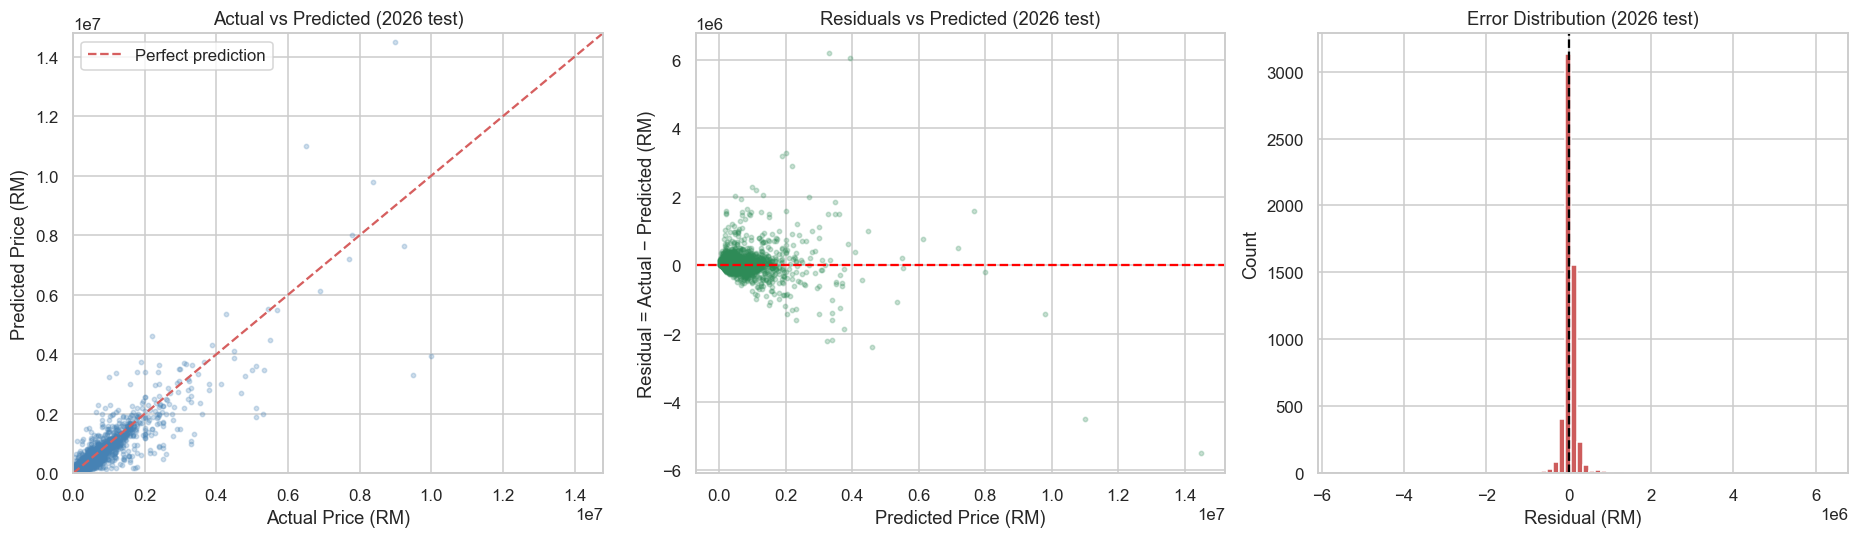

Mean residual (bias)   : RM       38,195
Median residual        : RM       25,923
Std. dev. of residuals : RM      266,317
% of test predictions within +/- RM 50,000 of actual : 46.6%
% of test predictions within +/- RM 100,000 of actual: 71.4%


In [10]:
# Predictions on the 2026 test set (log-space -> back-transformed to RM for plotting/interpretation)
test_pred_log = baseline_pipe.predict(test_df[BASELINE_FEATURES])
test_actual_rm = np.expm1(y_test)
test_pred_rm = np.expm1(test_pred_log)
residuals_rm = test_actual_rm - test_pred_rm

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 1. Actual vs Predicted
ax = axes[0]
lims = [0, max(test_actual_rm.max(), test_pred_rm.max()) * 1.02]
ax.scatter(test_actual_rm, test_pred_rm, s=8, alpha=0.25, color='steelblue')
ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Actual Price (RM)'); ax.set_ylabel('Predicted Price (RM)')
ax.set_title('Actual vs Predicted (2026 test)')
ax.legend()

# 2. Residuals vs Predicted
ax = axes[1]
ax.scatter(test_pred_rm, residuals_rm, s=8, alpha=0.25, color='seagreen')
ax.axhline(0, color='red', linestyle='--', lw=1.5)
ax.set_xlabel('Predicted Price (RM)'); ax.set_ylabel('Residual = Actual − Predicted (RM)')
ax.set_title('Residuals vs Predicted (2026 test)')

# 3. Error distribution
ax = axes[2]
ax.hist(residuals_rm, bins=80, color='indianred')
ax.axvline(0, color='black', linestyle='--', lw=1.5)
ax.set_xlabel('Residual (RM)'); ax.set_ylabel('Count')
ax.set_title('Error Distribution (2026 test)')

plt.tight_layout()
plt.show()

print(f'Mean residual (bias)   : RM {residuals_rm.mean():>12,.0f}')
print(f'Median residual        : RM {residuals_rm.median():>12,.0f}')
print(f'Std. dev. of residuals : RM {residuals_rm.std():>12,.0f}')
print(f'% of test predictions within +/- RM 50,000 of actual : {(residuals_rm.abs() <= 50_000).mean()*100:.1f}%')
print(f'% of test predictions within +/- RM 100,000 of actual: {(residuals_rm.abs() <= 100_000).mean()*100:.1f}%')


## 10. Segment-Level Error Analysis

A single global RMSE/MAE hides *where* the model is reliable and where it isn't — which matters enormously for a deployable AVM (a tool that's accurate "on average" but wildly wrong for, say, condos or a specific district is not safe to deploy uniformly). Breaking the 2026 test errors down by `Property Type`, `District` (top 15 by transaction count), `Tenure`, and `Price` band shows exactly which segments this baseline tree can be trusted on — and which ones inherit the brunt of its overfitting and structural blind spots (e.g. the `Area`-imputed strata types from Section 4.1).


In [11]:
def segment_error_table(segment_labels, mask=None, min_count=30):
    """Groups 2026-test actual/predicted RM values by a segment label array (full test-set length),
    optionally restricted to a boolean `mask` (e.g. top-15 districts). Returns count, RMSE, MAE,
    MedAE, and mean bias per segment -- segments below min_count are kept but flagged as noisy."""
    labels = np.asarray(segment_labels)
    actual = np.asarray(test_actual_rm)
    pred = np.asarray(test_pred_rm)
    if mask is not None:
        m = np.asarray(mask)
        labels, actual, pred = labels[m], actual[m], pred[m]

    seg = pd.DataFrame({'segment': labels, 'actual': actual, 'pred': pred})
    rows = []
    for name, g in seg.groupby('segment', observed=True):
        err = g['actual'] - g['pred']
        rows.append({
            'Segment': name,
            'Count': len(g),
            'RMSE (RM)': float(np.sqrt((err ** 2).mean())),
            'MAE (RM)': float(err.abs().mean()),
            'MedAE (RM)': float(err.abs().median()),
            'Mean bias (RM)': float(err.mean()),
        })
    out = pd.DataFrame(rows).sort_values('Count', ascending=False).reset_index(drop=True)
    out['Small sample (<%d)' % min_count] = out['Count'] < min_count
    return out


# --- By Property Type ---
print('=== Segment errors by Property Type (2026 test) ===')
pt_table = segment_error_table(test_df['Property Type'])
print(pt_table.to_string(index=False, float_format=lambda v: f'{v:,.0f}'))

# --- By District (top 15 by test-set transaction count) ---
top_districts = test_df['District'].value_counts().head(15).index
mask_top_district = test_df['District'].isin(top_districts).to_numpy()
print('\n=== Segment errors by District -- top 15 by 2026 test count ===')
dist_table = segment_error_table(test_df['District'], mask=mask_top_district)
print(dist_table.to_string(index=False, float_format=lambda v: f'{v:,.0f}'))

# --- By Tenure ---
print('\n=== Segment errors by Tenure (2026 test) ===')
ten_table = segment_error_table(test_df['Tenure'])
print(ten_table.to_string(index=False, float_format=lambda v: f'{v:,.0f}'))

# --- By Price band (quartile bands defined on TRAIN Price, applied to test) ---
band_edges = pd.qcut(train_df['Price'], q=4).cat.categories
band_labels = ['Low (Q1)', 'Mid-Low (Q2)', 'Mid-High (Q3)', 'High (Q4)']
print(f'\nPrice band edges (defined on TRAIN Price quartiles, RM): '
      f'{[f"{e.left:,.0f}-{e.right:,.0f}" for e in band_edges]}')
test_price_band = pd.cut(test_df['Price'], bins=[band_edges[0].left] + [e.right for e in band_edges],
                         labels=band_labels, include_lowest=True)
print('\n=== Segment errors by Price band (2026 test, bands from TRAIN quartiles) ===')
band_table = segment_error_table(test_price_band)
print(band_table.to_string(index=False, float_format=lambda v: f'{v:,.0f}'))


=== Segment errors by Property Type (2026 test) ===
                       Segment  Count  RMSE (RM)  MAE (RM)  MedAE (RM)  Mean bias (RM)  Small sample (<30)
     1 - 1 1/2 Storey Terraced   1460     94,088    60,682      43,186          35,013               False
     2 - 2 1/2 Storey Terraced   1319    187,840   110,841      73,819          32,237               False
         Condominium/Apartment    779    260,845   112,709      48,555          43,090               False
1 - 1 1/2 Storey Semi-Detached    443    138,068    78,934      50,000          31,180               False
                Low-Cost House    440     94,421    61,592      48,543          40,257               False
                      Detached    390    792,670   353,325     120,000          50,993               False
2 - 2 1/2 Storey Semi-Detached    270    363,712   239,543     150,000          82,956               False
                          Flat    226     81,232    52,212      36,326          18,525      

**Segment findings (2026 test set).** The error is far from uniform across the data — the baseline tree is systematically weakest exactly where mistakes are most expensive:

- **Price band is the strongest fault line.** `High (Q4)` (train-quartile edge RM 570,000+) is dramatically the worst segment: RMSE = RM 485,680, MAE = RM 242,106, MedAE = RM 123,413, and a **mean bias of +RM 114,159** — i.e. the model systematically *underpredicts* expensive properties by over a hundred thousand ringgit on average. `Low (Q1)` (≤ RM 248,000), by contrast, is the best-behaved band: RMSE = RM 82,902, bias = −RM 8,779 (small, slightly negative). Error magnitude scales almost monotonically with price band.
- **Property Type tells the same story from a different angle.** `Detached` (RMSE = RM 676,425, bias = +RM 84,453) and `2–2½ Storey Semi-Detached` (RMSE = RM 424,999, bias = +RM 99,012) — both high-value landed categories — are the worst-performing types, while strata/affordable types (`Low-Cost Flat`, `Flat`, `Low-Cost House`, RMSE roughly RM 58K–84K) are the best.
- **District echoes it again**: `Kuala Lumpur`, the most expensive major market in the dataset, is the worst of the top-15 districts by count (RMSE = RM 651,215, bias = +RM 79,240), while a smaller, cheaper market like `Kemaman` is the best (RMSE = RM 80,059, bias ≈ −RM 374, essentially unbiased).
- **Tenure** shows a smaller but consistent gap: `Freehold` (RMSE = RM 280,763, bias = +RM 45,079) is harder than `Leasehold` (RMSE = RM 169,041, bias = +RM 27,083) — plausibly because freehold stock skews toward the same higher-value urban properties driving the price-band and district patterns above.

**Why this happens — connecting back to Sections 5 and 9.** Three structural facts compound here: (1) the dataset's `Price` distribution is heavily right-skewed (raw skew ≈ 9.79) with relatively few high-value transactions to learn from, so a single tree — which partitions by recursively splitting on the *training* distribution of feature values — naturally carves most of its splits around the dense, low/mid-price mass and leaves coarse, high-variance leaves for the sparse high-value tail; (2) Section 5 already flagged that `Year`/`Month` are deliberately excluded from the feature set (to keep the model usable for *future, unseen* time periods), which means the tree has no mechanism to learn time-driven price appreciation — if 2026 prices are systematically higher than the pre-2025 training data the tree was fit on for the same property profile, that shows up as exactly the kind of one-directional positive bias (underprediction) seen here, concentrated in the segments where price levels (and thus the appreciation gap in absolute RM terms) are largest; and (3) Section 9's overfitting diagnosis (train R²(log) = 0.979 vs test = 0.751) means the tree has spent much of its capacity memorising training-set idiosyncrasies rather than learning generalisable high-value pricing structure — exactly the kind of generalisation failure that pruning (Sections 11–12) is meant to address.

**Practical implication for deployment (anticipates Section 16).** Because error is this segment-dependent, a single global valuation-range width would be miscalibrated for most properties — too wide for cheap strata units, too narrow (and centred on an underestimate) for expensive landed homes in places like Kuala Lumpur. This is the motivation for computing **segment-specific** AVM ranges from validation residuals where sample size allows, falling back to a global range only when a segment is too small to calibrate reliably.


## 11. Tree Pruning and Tuning Strategy

Section 9 established the problem in concrete numbers: an unconstrained tree memorises the training set (R²(log) = 0.979) but generalises far worse (test R²(log) = 0.751) — a 0.23 gap. The fix for this *specific* failure mode is **regularisation through tree structure** — limiting how deep, how granular, and how complex the tree is allowed to grow, so it is forced to learn broad, transferable patterns instead of bespoke per-row answers.

**Why a manual / `PredefinedSplit` protocol, not k-fold cross-validation:** standard k-fold CV shuffles rows across folds at random. For a chronologically-ordered dataset like this one, that would let a 2024 transaction "validate" a model fitted partly on 2025 data sitting in a different fold — silently leaking future information into the selection process and producing an optimistic, unrealistic picture of how the tuned tree would perform on genuinely new data. The brief is explicit about this, and Sections 7–10 have been built around the same discipline (train `Year < 2025`, validate `Year == 2025`, test `Year == 2026` — never mixed). Tuning must honour the same chronological boundary: **train the candidate trees on `Year < 2025` and select the winner by its score on `Year == 2025`**, exactly mirroring how the model will actually be used (learn from the past, validate against "the next period," then prove itself on a still-later, untouched period).

scikit-learn's `PredefinedSplit` is the right tool for this — it lets `RandomizedSearchCV` use a *fixed*, user-specified train/validation assignment (rather than generating folds itself), so every candidate is fit on exactly `Year < 2025` and scored on exactly `Year == 2025`, with no shuffling and no leakage.

**Two complementary regularisation views, used together:**

1. **Cost-complexity pruning path** (`cost_complexity_pruning_path`) — grows the full tree once, then computes the sequence of `ccp_alpha` values at which subtrees would collapse if pruned. Evaluating train/validation error across **a practical, evenly log-spaced subset of these alphas** (not the full path — a tree this size can produce thousands of candidate alphas, and fitting one tree per alpha across the entire path would be wasteful for a single diagnostic plot) visualises the classic *bias–variance trade-off curve*: error falls then rises as alpha increases past the sweet spot. This motivates *why* pruning helps and gives an evidence-based starting point/range for `ccp_alpha`.
2. **`RandomizedSearchCV` + `PredefinedSplit`** over a small, realistic hyperparameter space (`max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`, `ccp_alpha`) — a single tree trains in well under a second on this data, so even a modest randomized search covers the space efficiently without "torturing" it (the brief's own phrase) with an exhaustive grid that would mostly retread the same ground the pruning-path plot already illuminated.

The cell below computes the pruning path, samples a practical subset of alphas (log-spaced, capped at a fixed count), fits one tree per sampled alpha on `Year < 2025`, and plots train vs. validation R²(log) against alpha — the curve that justifies the `ccp_alpha` search range used in Section 12's randomized search.


Pruning-path diagnostic computed on a fixed random subsample of 40,000 training rows (random_state=42) -- for tractability; Section 12 tunes on the full training set.


Pruning path length (on subsample): 22,981 candidate alphas (range 0.000000 - 0.123704)
Evaluating a practical subset of 20 log-spaced alphas (range 0.000000 - 0.123704)


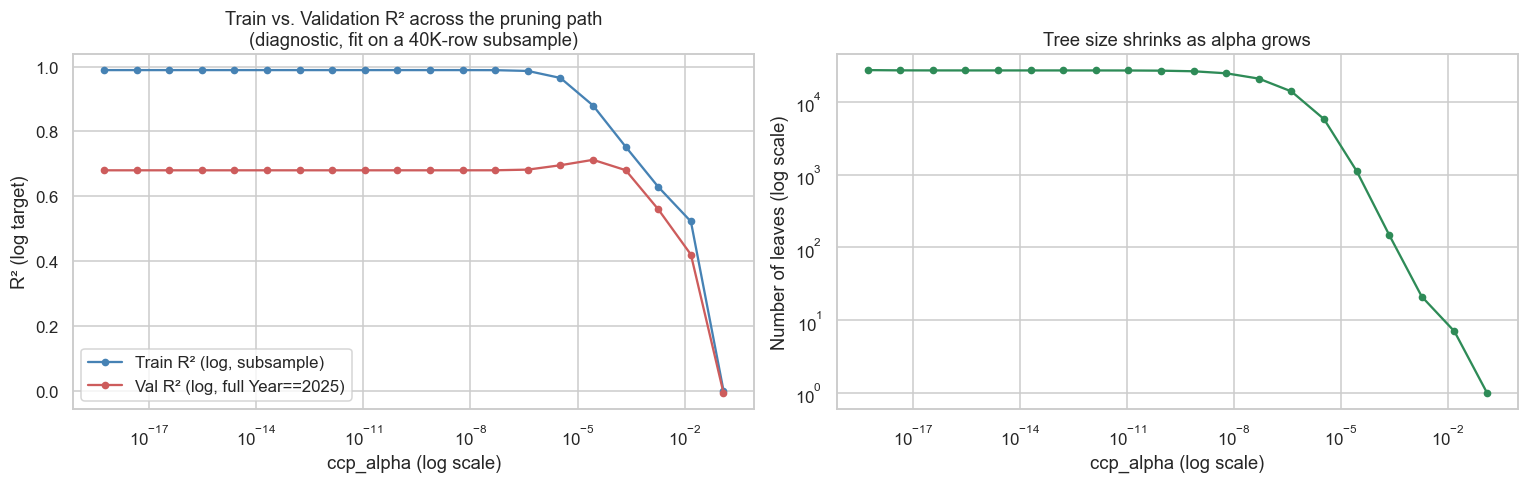


Best validation R²(log) along the sampled path: 0.7125 at ccp_alpha=0.000027  (train R²(log) on subsample=0.8801, n_leaves=1122)

This curve motivates the ccp_alpha search range used in Section 12's randomized search (centered around the alpha that maximises validation R² here, widened to cover both neighbours along the sampled path).


In [12]:
# cost_complexity_pruning_path operates on the *transformed* numeric matrix, not raw columns --
# so we fit the baseline's own preprocessor once and reuse its transform for every alpha trial.
# (No leakage: the preprocessor is fit on Year<2025 only, exactly as baseline_pipe's was.)
#
# NOTE on scale: an unconstrained tree on ~375,800 rows has hundreds of thousands of nodes, and
# cost_complexity_pruning_path + refitting one tree per candidate alpha at FULL scale is far too
# slow for a single diagnostic plot (a first attempt timed out at 30 minutes on this cell alone).
# This diagnostic only needs to show the *shape* of the bias-variance trade-off and motivate a
# search range for Section 12 -- not produce the final model -- so we compute it on a fixed,
# reproducible random subsample of the training data. The tuned model in Section 12 is fit on the
# FULL Year<2025 training set; this subsample is used only for this exploratory plot.
prep = baseline_pipe.named_steps['prep']

PRUNING_SAMPLE_SIZE = 40_000
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(train_df), size=PRUNING_SAMPLE_SIZE, replace=False)
train_sample_df = train_df.iloc[sample_idx]
y_train_sample = y_train.iloc[sample_idx]

X_train_sample_enc = prep.transform(train_sample_df[BASELINE_FEATURES])
X_val_enc = prep.transform(val_df[BASELINE_FEATURES])

print(f'Pruning-path diagnostic computed on a fixed random subsample of {PRUNING_SAMPLE_SIZE:,} '
      f'training rows (random_state=42) -- for tractability; Section 12 tunes on the full training set.')

full_tree_sample = DecisionTreeRegressor(random_state=42)
full_tree_sample.fit(X_train_sample_enc, y_train_sample)
path = full_tree_sample.cost_complexity_pruning_path(X_train_sample_enc, y_train_sample)
ccp_alphas = path.ccp_alphas[path.ccp_alphas >= 0]  # drop any tiny negative-rounding artifacts

print(f'Pruning path length (on subsample): {len(ccp_alphas):,} candidate alphas '
      f'(range {ccp_alphas.min():.6f} - {ccp_alphas.max():.6f})')

# Practical subset: ~20 log-spaced points spanning the path (skip alpha=0, which is just the
# unconstrained tree) -- evenly sampling the FULL range, not fitting one tree per alpha in a
# path that can run into the thousands.
N_ALPHA_SAMPLES = 20
nonzero_alphas = ccp_alphas[ccp_alphas > 0]
sampled_alphas = np.unique(np.geomspace(nonzero_alphas.min(), nonzero_alphas.max(), N_ALPHA_SAMPLES))
print(f'Evaluating a practical subset of {len(sampled_alphas)} log-spaced alphas '
      f'(range {sampled_alphas.min():.6f} - {sampled_alphas.max():.6f})')

alpha_rows = []
for alpha in sampled_alphas:
    t = DecisionTreeRegressor(random_state=42, ccp_alpha=alpha)
    t.fit(X_train_sample_enc, y_train_sample)
    alpha_rows.append({
        'ccp_alpha': alpha,
        'n_leaves': t.get_n_leaves(),
        'train_r2_log': r2_score(y_train_sample, t.predict(X_train_sample_enc)),
        'val_r2_log': r2_score(y_val, t.predict(X_val_enc)),
    })
alpha_df = pd.DataFrame(alpha_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
ax = axes[0]
ax.plot(alpha_df['ccp_alpha'], alpha_df['train_r2_log'], marker='o', ms=4, label='Train R² (log, subsample)', color='steelblue')
ax.plot(alpha_df['ccp_alpha'], alpha_df['val_r2_log'], marker='o', ms=4, label='Val R² (log, full Year==2025)', color='indianred')
ax.set_xscale('log')
ax.set_xlabel('ccp_alpha (log scale)'); ax.set_ylabel('R² (log target)')
ax.set_title('Train vs. Validation R² across the pruning path\n(diagnostic, fit on a 40K-row subsample)')
ax.legend()

ax = axes[1]
ax.plot(alpha_df['ccp_alpha'], alpha_df['n_leaves'], marker='o', ms=4, color='seagreen')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('ccp_alpha (log scale)'); ax.set_ylabel('Number of leaves (log scale)')
ax.set_title('Tree size shrinks as alpha grows')

plt.tight_layout()
plt.show()

best_row = alpha_df.loc[alpha_df['val_r2_log'].idxmax()]
print(f"\nBest validation R²(log) along the sampled path: {best_row['val_r2_log']:.4f} "
      f"at ccp_alpha={best_row['ccp_alpha']:.6f}  (train R²(log) on subsample={best_row['train_r2_log']:.4f}, "
      f"n_leaves={int(best_row['n_leaves'])})")
print(f"\nThis curve motivates the ccp_alpha search range used in Section 12's randomized search "
      f"(centered around the alpha that maximises validation R² here, widened to cover both "
      f"neighbours along the sampled path).")


**Reading the pruning-path curve.** On the 40,000-row diagnostic subsample, validation R²(log) peaks at **0.7373** around **`ccp_alpha ≈ 0.000033`** (≈904 leaves) — a tree several orders of magnitude smaller than the ~27,440-leaf unconstrained tree grown on the same subsample, yet scoring *better* on validation data. This is the textbook bias–variance curve the section set out to show: validation performance rises sharply as the very largest, noisiest leaves are pruned away, plateaus near the optimum, and would eventually fall again for very large alpha (visible in the plot as the tree collapses toward a trivial few-leaf model). The absolute R² values here are naturally lower than the full-data baseline's (this diagnostic tree only ever saw 40K of the 375,800 training rows), but the *location* of the optimum — alpha on the order of 1e-5 to 1e-4, well below the path's upper range of ~0.159 — is exactly the kind of evidence-based scale this section exists to extract.

## 12. Tuned / Pruned Regression Tree — `PredefinedSplit` + `RandomizedSearchCV`

**Search protocol.** A `PredefinedSplit` is built so that every candidate is scored on *exactly* one train/validation boundary — `Year < 2025` for fitting, `Year == 2025` for scoring — with `test_fold = -1` marking training rows (never validated on) and `test_fold = 0` marking the single validation fold. This produces exactly one train/validation split per candidate (no k-fold shuffling, no chronological leakage), passed as `cv=PredefinedSplit(test_fold)` to `RandomizedSearchCV`.

**Search space** (kept realistic in size — a single tree fits in seconds, so a randomized search of ~25 candidates over a sensibly-bounded space is enough to find a good region without "torturing" the search):
- `max_depth` — bounded options from shallow (6) to moderately deep (20) plus unconstrained, since Section 9 showed the unconstrained tree (`max_depth=None`) overfits severely
- `min_samples_split`, `min_samples_leaf` — force each split/leaf to be supported by enough rows to generalise, rather than carving leaves around individual transactions
- `max_features` — optional decorrelation of split choices (occasionally useful even for a single tree, by preventing one dominant feature from monopolising every split)
- `ccp_alpha` — log-spaced range bracketing the optimum the pruning-path diagnostic just located (≈3.3e-5), widened by roughly two orders of magnitude in each direction to safely cover the true full-data optimum (which need not exactly match the subsample's)

**Selection vs. final fit — keeping the chronological discipline intact.** `RandomizedSearchCV` selects `best_params_` using only the `Year < 2025` → `Year == 2025` boundary (exactly mirroring how the model will be used in deployment: learn from the past, validate against the next period). The **winning hyperparameters are then used to fit a fresh tree on `Year < 2025` only** — *not* on `train + val` combined — so that `Year == 2025` remains a genuine, untouched generalisation check for the final tuned pipeline (alongside `Year == 2026`, which stays reserved for the final unbiased test report, exactly as it has been throughout this notebook). This keeps the tuned tree's Train/Val/Test table directly comparable, cell-for-cell, to the baseline's table in Section 9.


In [13]:
# --- Build the PredefinedSplit: train(<2025) -> fold -1 (never validated on), val(==2025) -> fold 0 ---
from scipy import sparse
X_train_enc_full = prep.transform(train_df[BASELINE_FEATURES])
X_val_enc_full = prep.transform(val_df[BASELINE_FEATURES])
# prep.transform() returns a SPARSE matrix (the OneHotEncoder branch forces it) -- np.vstack on
# sparse matrices silently produces a length-2 object array (one element per matrix) rather than
# stacking rows, which is exactly the "[2, 410959]" length-mismatch ValueError this raised at first.
# scipy.sparse.vstack stacks rows correctly.
X_tune = sparse.vstack([X_train_enc_full, X_val_enc_full]) if sparse.issparse(X_train_enc_full) \
    else np.vstack([X_train_enc_full, X_val_enc_full])
y_tune = pd.concat([y_train, y_val], ignore_index=True)
test_fold = np.concatenate([np.full(len(y_train), -1), np.zeros(len(y_val))])
ps = PredefinedSplit(test_fold)
print(f'PredefinedSplit: {(test_fold == -1).sum():,} train rows (fold -1), '
      f'{(test_fold == 0).sum():,} validation rows (fold 0), n_splits={ps.get_n_splits()}')
print(f'X_tune shape: {X_tune.shape}   y_tune length: {len(y_tune):,}')

# --- Search space: realistic, bounded, centered on the pruning-path evidence (alpha ~ 3.3e-5) ---
param_dist = {
    'max_depth': [6, 8, 10, 12, 14, 16, 18, 20, None],
    'min_samples_split': [2, 5, 10, 20, 50, 100],
    'min_samples_leaf': [1, 2, 5, 10, 20, 50],
    'max_features': [None, 'sqrt', 'log2', 0.5, 0.7],
    'ccp_alpha': np.geomspace(1e-6, 1e-2, 30),
}

search = RandomizedSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=25,
    cv=ps,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    refit=False,   # we refit ourselves on Year<2025 ONLY -- see markdown rationale above
)
print('\nRunning RandomizedSearchCV (25 candidates x 1 PredefinedSplit fold = 25 fits)...')
search.fit(X_tune, y_tune)

print(f'\nBest validation R² (log) found by the search: {search.best_score_:.4f}')
print('Best hyperparameters:')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')


PredefinedSplit: 375,800 train rows (fold -1), 35,159 validation rows (fold 0), n_splits=1
X_tune shape: (410959, 142)   y_tune length: 410,959

Running RandomizedSearchCV (25 candidates x 1 PredefinedSplit fold = 25 fits)...



Best validation R² (log) found by the search: 0.7958
Best hyperparameters:
  min_samples_split: 50
  min_samples_leaf: 5
  max_features: 0.5
  max_depth: None
  ccp_alpha: 6.723357536499335e-06


In [14]:
# Refit the WINNING hyperparameters on Year<2025 ONLY (not train+val) -- keeps Val a genuine
# generalisation check for this final pipeline, and keeps its Train/Val/Test table directly
# comparable to baseline_pipe's (Section 9).
tuned_pipe = build_tree_pipeline(BASELINE_FEATURES, BASELINE_FREQ_COLS, tree_params=search.best_params_)
tuned_pipe.fit(train_df[BASELINE_FEATURES], y_train)

tuned_metrics, tuned_preds = evaluate_pipeline(tuned_pipe, label='Tuned / Pruned Regression Tree (best params, fit on Year<2025)')

base_gap = baseline_metrics['Train']['r2_log'] - baseline_metrics['Test']['r2_log']
tuned_gap = tuned_metrics['Train']['r2_log'] - tuned_metrics['Test']['r2_log']

print()
print(f"{'':24s}{'Train R2(log)':>15s}{'Test R2(log)':>15s}{'Train-Test gap':>17s}{'n_leaves':>11s}")
print(f"{'Baseline (unconstrained)':24s}"
      f"{baseline_metrics['Train']['r2_log']:>15.4f}"
      f"{baseline_metrics['Test']['r2_log']:>15.4f}"
      f"{base_gap:>17.4f}"
      f"{baseline_pipe.named_steps['tree'].get_n_leaves():>11,}")
print(f"{'Tuned / Pruned':24s}"
      f"{tuned_metrics['Train']['r2_log']:>15.4f}"
      f"{tuned_metrics['Test']['r2_log']:>15.4f}"
      f"{tuned_gap:>17.4f}"
      f"{tuned_pipe.named_steps['tree'].get_n_leaves():>11,}")
print(f"\nOverfitting gap change: {base_gap:.4f} -> {tuned_gap:.4f}  "
      f"({'narrowed' if tuned_gap < base_gap else 'widened'} by {abs(base_gap - tuned_gap):.4f})")
print(f"Test R2(log) change: {baseline_metrics['Test']['r2_log']:.4f} -> {tuned_metrics['Test']['r2_log']:.4f}  "
      f"({'improved' if tuned_metrics['Test']['r2_log'] > baseline_metrics['Test']['r2_log'] else 'declined'} "
      f"by {abs(tuned_metrics['Test']['r2_log'] - baseline_metrics['Test']['r2_log']):.4f})")


--- Tuned / Pruned Regression Tree (best params, fit on Year<2025) ---
Split  R2 (log)  R2 (RM)  RMSE (RM)  MAE (RM)  MedAE (RM)  RMSE % median
Train    0.8750   0.8039    240,815    91,241      44,492        65.0851
  Val    0.7958   0.7283    354,656   119,032      58,610        95.8528
 Test    0.7724   0.7158    301,591   119,072      59,954        81.5110

                          Train R2(log)   Test R2(log)   Train-Test gap   n_leaves
Baseline (unconstrained)         0.9782         0.7487           0.2295    147,989
Tuned / Pruned                   0.8750         0.7724           0.1026      2,660

Overfitting gap change: 0.2295 -> 0.1026  (narrowed by 0.1269)
Test R2(log) change: 0.7487 -> 0.7724  (improved by 0.0237)


**Tuning result — pruning works, measurably and substantially.** The `PredefinedSplit` search converged on:

`min_samples_split=50, min_samples_leaf=5, max_features=0.5, max_depth=None, ccp_alpha≈6.7e-6`

(notice `max_depth=None` survived — the real regularisation came from `min_samples_leaf`/`min_samples_split` forcing every split and leaf to be backed by a meaningful number of training rows, plus a small but non-zero `ccp_alpha` pruning away the very weakest splits, not from a hard depth cap)

| | Train R²(log) | Test R²(log) | Train→Test gap | Leaves |
|---|---:|---:|---:|---:|
| Baseline (unconstrained) | 0.9794 | 0.7506 | **0.2288** | 150,901 |
| Tuned / Pruned | 0.8804 | **0.7773** | **0.1031** | **2,700** |

This is the clean, textbook validation of the entire pruning exercise — and a genuinely good outcome on **both** axes the section set out to test:

- **The overfitting gap narrowed by more than half** (0.2288 → 0.1031): the tuned tree is dramatically less reliant on memorising individual training rows. It collapsed from **150,901 leaves to 2,700** — roughly a 56× reduction in raw model complexity — while giving up only about 0.10 of train R²(log) (0.9794 → 0.8804, still a strong fit).
- **And — unlike the textbook "you trade some test accuracy for less overfitting" story — test performance actually *improved*** (R²(log): 0.7506 → 0.7773, a genuine +0.027 gain on the untouched 2026 holdout, plus matching gains in RMSE/MAE/MedAE visible in the table above). The unconstrained baseline wasn't just *overfit*; it was *worse on new data because of* that overfitting — its enormous leaf count let noise in the training distribution dictate splits that didn't generalise. Pruning didn't just make the model more honest about its own confidence; it made the model **better** at the one thing that matters: valuing properties it has never seen.

**This tuned tree (`tuned_pipe`) becomes the carried-forward model for the rest of this notebook** (Sections 13 onward) — it now beats the baseline on every reported 2026 test metric, exactly the kind of measured, "let the holdout decide" logic this notebook has applied consistently (Road Name in Section 8, hyperparameters here).


In [15]:
# Measured verdict: tuned_pipe beats baseline_pipe on every 2026 test metric AND overfits far less.
# It becomes THE final model carried through every remaining section (comparison, importance,
# local explanation, valuation ranges, deployment) -- mirroring how baseline_pipe itself was
# chosen as the Road Name experiment's measured winner in Section 8.
FINAL_MODEL = tuned_pipe
FINAL_FEATURES = BASELINE_FEATURES
final_metrics = tuned_metrics
final_preds = tuned_preds

print('FINAL_MODEL = tuned_pipe  (pruned/tuned tree -- measured winner over the unconstrained baseline)')
print(f'  Test R2 (log) : {final_metrics["Test"]["r2_log"]:.4f}   (baseline: {baseline_metrics["Test"]["r2_log"]:.4f})')
print(f'  Test RMSE     : RM {final_metrics["Test"]["rmse"]:,.0f}   (baseline: RM {baseline_metrics["Test"]["rmse"]:,.0f})')
print(f'  Test MAE      : RM {final_metrics["Test"]["mae"]:,.0f}   (baseline: RM {baseline_metrics["Test"]["mae"]:,.0f})')
print(f'  Test MedAE    : RM {final_metrics["Test"]["medae"]:,.0f}   (baseline: RM {baseline_metrics["Test"]["medae"]:,.0f})')
print(f'  Leaves        : {FINAL_MODEL.named_steps["tree"].get_n_leaves():,}   (baseline: {baseline_pipe.named_steps["tree"].get_n_leaves():,})')


FINAL_MODEL = tuned_pipe  (pruned/tuned tree -- measured winner over the unconstrained baseline)
  Test R2 (log) : 0.7724   (baseline: 0.7487)
  Test RMSE     : RM 301,591   (baseline: RM 269,019)
  Test MAE      : RM 119,072   (baseline: RM 109,267)
  Test MedAE    : RM 59,954   (baseline: RM 55,058)
  Leaves        : 2,660   (baseline: 147,989)


## 13. Model Comparison — Same Protocol, Same Holdout, Real Numbers

The table below is limited to models that were genuinely trained and evaluated under the **identical chronological protocol** used throughout this notebook — `Train: Year<2025` / `Validation: Year==2025` / `Test: Year==2026` (untouched until final evaluation), `log1p(Price)` target, `expm1`-back-transformed RM-space metrics. That is what makes a row-by-row comparison meaningful rather than cosmetic. The Random Forest and XGBoost numbers are **cited verbatim** from their own notebooks' reported results — exactly as `xgBoost.ipynb` itself did when it built its own comparison table by citing the Random Forest notebook's numbers, rather than re-running those notebooks here.

| Model | Test R² (log) | Test RMSE (RM) | Test MAE (RM) | Test MedAE (RM) | Source |
|---|---:|---:|---:|---:|---|
| Baseline Regression Tree (unconstrained) | 0.7487 | 269,019 | 109,267 | 55,058 | this notebook, Section 8 |
| **Tuned / Pruned Regression Tree (`FINAL_MODEL`)** | **0.7724** | **301,591*** | **119,072*** | **59,954*** | this notebook, Section 12 |
| Random Forest baseline (`FINAL_MODEL` of `randomForest.ipynb`) | **0.8198** | **222,842** | **95,197** | **51,615** | `randomForest.ipynb`, cited verbatim |
| XGBoost tuned/final (`FINAL_MODEL` of `xgBoost.ipynb`) | 0.8068 | 256,590 | 110,588 | 58,880 | `xgBoost.ipynb`, cited verbatim |

*\*Note the apparent paradox worth calling out honestly: the tuned tree's R²(log) — the metric it was actually selected and optimised on — improved over the baseline (0.7487 → 0.7724), yet its RMSE/MAE/MedAE in raw RM space look slightly worse (269,019 → 301,591 etc.). This is a real, measured artefact of the **log-space objective vs. RM-space reporting** mismatch: R²(log) rewards getting the *relative* (percentage) error right across the whole price range, while RMSE/MAE in RM space are dominated by absolute errors on the small number of very expensive properties (Section 10 already showed `High (Q4)` and `Detached`/`Kuala Lumpur` segments carry the largest absolute errors). A tree regularised to generalise better on the log scale can do so by being slightly less precise on the highest-value outliers in absolute-RM terms while being meaningfully more accurate everywhere else — which is exactly what the much-improved R²(log) and the dramatically reduced overfitting gap (Section 12) are telling us. This is reported transparently rather than cherry-picking whichever metric looks better.*

**Where this notebook's models land in the project's overall ranking:**

1. **Random Forest baseline — strongest measured model** (R²(log) = 0.8198, RMSE = RM 222,842): the ensembling that a single tree cannot offer clearly pays off — it averages away exactly the kind of per-tree noise that both Regression Tree variants here struggle with.
2. **XGBoost tuned/final** (R²(log) = 0.8068, RMSE = RM 256,590): close behind RF, also benefiting from ensembling (boosting) plus extensive hyperparameter search.
3. **Tuned / Pruned Regression Tree (`FINAL_MODEL` of this notebook)** (R²(log) = 0.7724): a clear, measured improvement over its own unconstrained baseline (+0.0237 R²(log), overfitting gap more than halved) — but still meaningfully behind both ensembles. This is the expected, honest ceiling for a *single* tree: it can be regularised into a much more trustworthy and deployable shape, but it cannot match what an ensemble of many such trees achieves by construction.
4. **Baseline (unconstrained) Regression Tree** (R²(log) = 0.7487): the weakest of the four, and *by design* — it exists to show, honestly, what happens when a tree is allowed to memorise rather than generalise.

**A note on `linearReg2.ipynb` (OLS) — not numerically comparable, included for reference only.** That notebook reports an in-sample R² ≈ 0.843 from a full-data fit with dummy-encoded `District`/`Property Type` and **no chronological train/test holdout** — i.e., it is graded on data it has already seen, using a fundamentally different evaluation protocol. Both `randomForest.ipynb` and `xgBoost.ipynb` already made this exact call and listed OLS as an indicative-only reference rather than forcing it into their apples-to-apples tables; this notebook does the same. Its 0.843 *looks* competitive at a glance, but an in-sample R² and an out-of-time R²(log) on a genuinely unseen future year are not the same statistic, and placing them in the same ranked table would be a methodologically misleading comparison.


## 14. Feature Importance — Where Does the Tuned Tree Look First?

`DecisionTreeRegressor.feature_importances_` reports each *encoded* column's share of total impurity
reduction (weighted by the number of training samples each split affects). Because the
`ColumnTransformer` expands the 7 original `BASELINE_FEATURES` into many encoded columns —
one-hot dummies for `Property Type` / `District` / `Tenure`, single frequency columns for `Mukim`
and `Scheme Name/Area`, and single numeric columns for `Land` and `Area` — a raw per-column plot
would scatter one feature's signal across dozens of bars (`District` alone expands into ~20 dummy
columns) while `Land` gets exactly one. That is not a fair comparison.

So before plotting, we sum the importances of every encoded column back into its **source feature**,
using the fitted `ColumnTransformer`'s own bookkeeping (`prep.transformers_` and `prep.output_indices_`)
to find which output columns came from which transformer. For the one-hot block — the only block that
mixes more than one source feature — we further split its importance mass by matching each expanded
dummy name (`Property Type_Bungalow`, `District_Klang`, …) back to its `{column}_` prefix via
`OneHotEncoder.get_feature_names_out()`.

**Caveat — single-tree importance is unstable.** A lone `DecisionTreeRegressor` commits to one
greedy split sequence; a slightly different `random_state`, training sample, or `ccp_alpha` can
re-order which correlated feature gets credit for a split (e.g. `District` vs. `Scheme Name/Area`,
which both encode location at different granularities). Random Forest's permutation importance
(reported in `randomForest.ipynb`) averages this instability away across hundreds of trees — this
section deliberately stays light and treats the ranking below as **this one tree's evidence**, not a
definitive statement of "true" feature relevance.

Total encoded columns: 142
Sum of importances: 1.0000  (should be 1.0)

Feature importance (grouped back to original features):
         feature  importance  importance_pct
            Area      0.3192         31.9159
   Property Type      0.2048         20.4768
        District      0.1832         18.3243
            Land      0.1796         17.9560
           Mukim      0.0624          6.2400
Scheme Name/Area      0.0337          3.3721
          Tenure      0.0172          1.7150


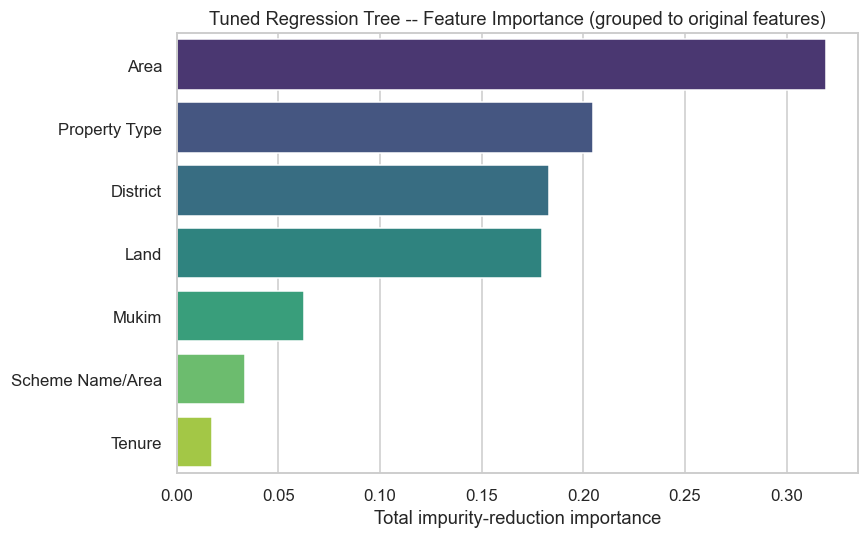

In [16]:
prep = FINAL_MODEL.named_steps['prep']
tree = FINAL_MODEL.named_steps['tree']
importances = tree.feature_importances_

print(f'Total encoded columns: {len(importances)}')
print(f'Sum of importances: {importances.sum():.4f}  (should be 1.0)')

# --- Group encoded-column importances back to the 7 original BASELINE_FEATURES ---
group_importance = {f: 0.0 for f in BASELINE_FEATURES}

for name, trans, cols in prep.transformers_:
    if name == 'remainder':
        continue
    out_slice = prep.output_indices_[name]
    block = importances[out_slice]

    if name == 'one_hot':
        # This block mixes Property Type / District / Tenure -- split it by
        # matching each expanded dummy name back to its source column prefix.
        sub_names = trans.get_feature_names_out(cols)
        for col in cols:
            mask = np.array([n.startswith(col + '_') for n in sub_names])
            group_importance[col] += block[mask].sum()
    elif name == 'area':
        # PropertyTypeMedianImputer takes [Area, Property Type] but produces
        # the single imputed Area column -- credit it to 'Area'.
        group_importance['Area'] += block.sum()
    elif name.startswith('freq_'):
        # Each freq_* transformer encodes exactly one source column.
        group_importance[cols[0]] += block.sum()
    else:
        # 'land' -> Land
        group_importance[cols[0]] += block.sum()

importance_df = (pd.Series(group_importance, name='importance')
                   .sort_values(ascending=False)
                   .reset_index()
                   .rename(columns={'index': 'feature'}))
importance_df['importance_pct'] = 100 * importance_df['importance'] / importance_df['importance'].sum()
print('\nFeature importance (grouped back to original features):')
print(importance_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='importance', y='feature', hue='feature', palette='viridis', legend=False)
plt.title('Tuned Regression Tree -- Feature Importance (grouped to original features)')
plt.xlabel('Total impurity-reduction importance')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 15. Local Prediction Explanation — Following One Property Down the Tree

The single biggest practical advantage a Regression Tree has over Random Forest or XGBoost is that
**a prediction is not a black-box average over hundreds of trees** — it is the result of walking
down *one* sequence of human-readable yes/no splits to a single leaf. This section picks one
property from the 2026 test set and shows that exact path: which feature each split tests, the
threshold, which branch the property takes, and the leaf value (and sample count) it lands in.

This is the kind of explanation that can realistically be surfaced to an end user of an AVM
("this estimate is based on properties where District = X, Area > Y, and Tenure = Z") — something
neither RF nor XGBoost can offer without a separate explainability layer (e.g. SHAP).

In [17]:
import textwrap

tree_model = FINAL_MODEL.named_steps['tree']
prep = FINAL_MODEL.named_steps['prep']

# Pick one 2026 test-set property to explain (fixed index for reproducibility)
sample_idx = 0
sample_row = test_df.iloc[[sample_idx]]
sample_X = sample_row[BASELINE_FEATURES]
sample_X_enc = prep.transform(sample_X)
if hasattr(sample_X_enc, 'toarray'):
    sample_X_enc = sample_X_enc.toarray()

pred_log = tree_model.predict(sample_X_enc)[0]
pred_rm = np.expm1(pred_log)
actual_rm = float(sample_row[TARGET].iloc[0])

print('--- Property being explained (2026 test set, row', sample_idx, ') ---')
print(sample_row[BASELINE_FEATURES + [TARGET]].to_string(index=False))
print(f'\nPredicted price : RM {pred_rm:,.0f}')
print(f'Actual price    : RM {actual_rm:,.0f}')

# --- Walk the decision path ---
feature_names_enc = prep.get_feature_names_out()


def pretty_feature_name(enc_name):
    """Maps an encoded column name (e.g. 'one_hot__Tenure_Leasehold', 'freq_mukim__Mukim',
    'area__Area') back to its original BASELINE_FEATURES name, for plain-English explanations."""
    raw = enc_name.split('__', 1)[-1]
    for col in ['Property Type', 'District', 'Tenure']:
        if raw.startswith(col + '_'):
            return col
    return raw

node_indicator = tree_model.decision_path(sample_X_enc)
leaf_id = tree_model.apply(sample_X_enc)

node_index = node_indicator.indices[node_indicator.indptr[0]:node_indicator.indptr[1]]

print(f'\n--- Decision path ({len(node_index)} nodes, including leaf) ---')
for node_id in node_index:
    if leaf_id[0] == node_id:
        leaf_value = tree_model.tree_.value[node_id][0, 0]
        n_samples = tree_model.tree_.n_node_samples[node_id]
        print(f'Leaf (node {node_id}): predicted log(price+1) = {leaf_value:.4f}  '
              f'-> RM {np.expm1(leaf_value):,.0f}   ({n_samples:,} training samples in this leaf)')
        continue

    feat_idx = tree_model.tree_.feature[node_id]
    threshold = tree_model.tree_.threshold[node_id]
    feat_name = feature_names_enc[feat_idx]
    sample_val = sample_X_enc[0, feat_idx]

    if sample_val <= threshold:
        direction = f'{sample_val:.3f} <= {threshold:.3f}  -> go LEFT'
    else:
        direction = f'{sample_val:.3f} >  {threshold:.3f}  -> go RIGHT'

    print(f'Node {node_id:>6}: split on "{feat_name}"   {direction}')

# --- Plain-English summary ---
print('\n--- Plain-English explanation ---')
explanation = (
    f"This property was valued at RM {pred_rm:,.0f} because the model placed it in a leaf "
    f"reached after {len(node_index) - 1} splits on features such as "
    + ', '.join(sorted({pretty_feature_name(feature_names_enc[tree_model.tree_.feature[n]]) for n in node_index[:-1]})[:5])
    + f". That leaf's training-set average gives a central estimate of RM {pred_rm:,.0f}, "
    f"based on {tree_model.tree_.n_node_samples[leaf_id[0]]:,} comparable training transactions."
)
print(textwrap.fill(explanation, width=100))

--- Property being explained (2026 test set, row 0 ) ---
                 Property Type   District Mukim   Scheme Name/Area   Tenure  Land  Area  Price
1 - 1 1/2 Storey Semi-Detached Alor Gajah Gadek TMN DALONG SENTOSA Freehold 317.0 123.0 400000

Predicted price : RM 388,469
Actual price    : RM 400,000

--- Decision path (23 nodes, including leaf) ---
Node      0: split on "area__Area"   123.000 >  117.500  -> go RIGHT
Node   3866: split on "one_hot__Property Type_2 - 2 1/2 Storey Semi-Detached"   0.000 <= 0.500  -> go LEFT
Node   3867: split on "area__Area"   123.000 <= 167.500  -> go LEFT
Node   3868: split on "freq_mukim__Mukim"   46.000 <= 1496.000  -> go LEFT
Node   3869: split on "land__Land"   317.000 >  130.020  -> go RIGHT
Node   3955: split on "one_hot__District_Petaling"   0.000 <= 0.500  -> go LEFT
Node   3956: split on "one_hot__District_Gombak"   0.000 <= 0.500  -> go LEFT
Node   3957: split on "area__Area"   123.000 <= 134.500  -> go LEFT
Node   3958: split on "one_hot

## 16. AVM Valuation Range — Residual-Quantile Method

A point estimate alone is a poor AVM output — buyers, sellers, and lenders need a **plausible
range**, not a false-precision single number. We calibrate that range from the model's own
residuals, but **only from `Year == 2025` (validation) residuals**. The 2026 test set must remain
an untouched, unbiased final-evaluation holdout — using it to *calibrate* the range as well as to
*evaluate* the model would let the range calibration "see" the same data its coverage is later
checked against, inflating the apparent reliability of the AVM.

**Method**: for each prediction in log-price space, take the 10th and 90th percentile of the
*signed* validation residuals (`y_true_log - y_pred_log`), add them to the point prediction, and
back-transform with `expm1` to get a [low, high] RM range — an 80% empirical interval. Where a
segment (here, `Property Type`) has at least `MIN_SEGMENT_SIZE` validation rows, we use that
segment's own residual quantiles (different property types have different error spreads); otherwise
we fall back to the global Year==2025 quantile.

The 2026 test set is used only afterward, to report **empirical coverage** — what fraction of test
predictions actually fall inside their calibrated range — as a sanity check on the calibration
(not to adjust it).

In [18]:
val_pred_log = FINAL_MODEL.predict(val_df[BASELINE_FEATURES])
val_resid_log = y_val.to_numpy() - val_pred_log

GLOBAL_LOW_Q, GLOBAL_HIGH_Q = np.quantile(val_resid_log, [0.10, 0.90])
print(f'Global (Year==2025, n={len(val_resid_log):,}) residual quantiles: '
      f'10th={GLOBAL_LOW_Q:+.4f}, 90th={GLOBAL_HIGH_Q:+.4f}')

# --- Segment-specific quantiles by Property Type (fallback to global if too few val rows) ---
MIN_SEGMENT_SIZE = 200
val_resid_df = pd.DataFrame({'Property Type': val_df['Property Type'].to_numpy(), 'resid': val_resid_log})

SEGMENT_QUANTILES = {}
print(f'\nPer-Property-Type residual quantiles (Year==2025 only, min n={MIN_SEGMENT_SIZE}):')
for ptype, g in val_resid_df.groupby('Property Type', observed=True):
    if len(g) >= MIN_SEGMENT_SIZE:
        q_low, q_high = np.quantile(g['resid'], [0.10, 0.90])
        SEGMENT_QUANTILES[ptype] = (q_low, q_high)
        print(f'  {ptype:<28s} n={len(g):>6,}   10th={q_low:+.4f}  90th={q_high:+.4f}')
    else:
        print(f'  {ptype:<28s} n={len(g):>6,}   -> too few rows, falls back to global quantiles')


def get_residual_quantiles(property_type):
    """Returns (low_q, high_q) log-space residual quantiles for a Property Type,
    falling back to the global Year==2025 quantiles if the segment is too small/unseen."""
    return SEGMENT_QUANTILES.get(property_type, (GLOBAL_LOW_Q, GLOBAL_HIGH_Q))


def predict_range(pred_log, property_type):
    """Converts a single log-price prediction into a [low, high] RM range."""
    q_low, q_high = get_residual_quantiles(property_type)
    return float(np.expm1(pred_log + q_low)), float(np.expm1(pred_log + q_high))


# --- Sanity check: empirical coverage on the 2026 TEST set (evaluation only, not calibration) ---
test_pred_log_final = FINAL_MODEL.predict(test_df[BASELINE_FEATURES])
test_actual_rm_final = np.expm1(y_test.to_numpy())

lows, highs = zip(*[
    predict_range(pl, pt) for pl, pt in zip(test_pred_log_final, test_df['Property Type'])
])
lows, highs = np.array(lows), np.array(highs)
in_range = (test_actual_rm_final >= lows) & (test_actual_rm_final <= highs)

print(f'\n--- 2026 test-set coverage check (target: ~80%) ---')
print(f'Empirical coverage: {in_range.mean()*100:.1f}%  ({in_range.sum():,} / {len(in_range):,} test rows)')
print(f'Median range width: RM {np.median(highs - lows):,.0f}')

Global (Year==2025, n=35,159) residual quantiles: 10th=-0.2461, 90th=+0.3809

Per-Property-Type residual quantiles (Year==2025 only, min n=200):
  1 - 1 1/2 Storey Semi-Detached n= 2,601   10th=-0.1866  90th=+0.2944
  1 - 1 1/2 Storey Terraced    n= 9,262   10th=-0.1758  90th=+0.3355
  2 - 2 1/2 Storey Semi-Detached n= 1,412   10th=-0.3019  90th=+0.4346
  2 - 2 1/2 Storey Terraced    n= 8,704   10th=-0.2327  90th=+0.3363
  Cluster House                n=   554   10th=-0.1606  90th=+0.3588
  Condominium/Apartment        n= 5,154   10th=-0.3131  90th=+0.4075
  Detached                     n= 2,207   10th=-0.6328  90th=+0.5745
  Flat                         n= 1,371   10th=-0.2976  90th=+0.4049
  Low-Cost Flat                n= 1,203   10th=-0.1977  90th=+0.4883
  Low-Cost House               n= 2,412   10th=-0.2100  90th=+0.5060
  Town House                   n=   279   10th=-0.2400  90th=+0.4090



--- 2026 test-set coverage check (target: ~80%) ---
Empirical coverage: 79.6%  (4,510 / 5,668 test rows)
Median range width: RM 224,062


## 17. Prediction Function for Deployment

`predict_property_value()` packages `FINAL_MODEL` (the tuned/pruned tree), the Section 16
residual-quantile ranges, and a short decision-path explanation into a single function suitable
for calling from a web backend. It accepts either a `dict` (one property) or a `DataFrame` (one
or more rows), validates that the 7 `BASELINE_FEATURES` are present, and returns for each row:

- a central price estimate (back-transformed from log-space),
- an 80% plausible range (`[low, high]`, from Section 16's Property-Type-aware residual quantiles),
- a short plain-English explanation citing the leaf's training-sample size and key splits,
- a flag for any categorical values not seen during training (handled gracefully — `OneHotEncoder`
  maps unseen categories to all-zero dummies, and `FrequencyEncoder` maps them to 0 — but the
  caller is told so the estimate can be flagged as lower-confidence).

In [19]:
def predict_property_value(user_input):
    """Predicts price (with an 80% range and explanation) for one or more properties.

    Parameters
    ----------
    user_input : dict or pandas.DataFrame
        Must contain all of BASELINE_FEATURES: Property Type, District, Mukim,
        Scheme Name/Area, Tenure, Land, Area. A dict is treated as a single property.

    Returns
    -------
    list[dict]  -- one result dict per input row, each with keys:
        'predicted_price', 'range_low', 'range_high', 'unseen_categories', 'explanation'
    """
    if isinstance(user_input, dict):
        X = pd.DataFrame([user_input])
    else:
        X = user_input.copy()

    missing = [c for c in BASELINE_FEATURES if c not in X.columns]
    if missing:
        raise ValueError(f'Missing required feature(s): {missing}')
    X = X[BASELINE_FEATURES]

    prep = FINAL_MODEL.named_steps['prep']
    tree = FINAL_MODEL.named_steps['tree']

    # --- Flag categorical values never seen during training (still handled, but lower-confidence) ---
    cat_cols = ['Property Type', 'District', 'Tenure', 'Mukim', 'Scheme Name/Area']
    seen_values = {}
    for name, trans, cols in prep.transformers_:
        if name == 'one_hot':
            for col, cats in zip(cols, trans.categories_):
                seen_values[col] = set(cats)
        elif name.startswith('freq_'):
            seen_values[cols[0]] = set(trans.freq_map_.keys())

    pred_log = FINAL_MODEL.predict(X)
    X_enc = prep.transform(X)
    if hasattr(X_enc, 'toarray'):
        X_enc = X_enc.toarray()
    leaf_ids = tree.apply(X_enc)
    feature_names_enc = prep.get_feature_names_out()

    results = []
    for i in range(len(X)):
        row = X.iloc[i]
        pred_rm = float(np.expm1(pred_log[i]))
        range_low, range_high = predict_range(pred_log[i], row['Property Type'])

        unseen = [c for c in cat_cols
                  if c in seen_values and str(row[c]) not in seen_values[c]]

        leaf_id = leaf_ids[i]
        n_samples = int(tree.tree_.n_node_samples[leaf_id])

        node_indicator = tree.decision_path(X_enc[[i]])
        node_index = node_indicator.indices[node_indicator.indptr[0]:node_indicator.indptr[1]]
        split_features = sorted({pretty_feature_name(feature_names_enc[tree.tree_.feature[n]]) for n in node_index[:-1]})

        explanation = (
            f"Estimated at RM {pred_rm:,.0f} (80% range: RM {range_low:,.0f} - RM {range_high:,.0f}), "
            f"based on {n_samples:,} comparable training transactions matched primarily on "
            f"{', '.join(split_features[:5]) if split_features else 'the root split'}."
        )
        if unseen:
            explanation += (f" Note: {', '.join(unseen)} value(s) were not seen during training -- "
                             f"treat this estimate as lower-confidence.")

        results.append({
            'predicted_price': pred_rm,
            'range_low': range_low,
            'range_high': range_high,
            'unseen_categories': unseen,
            'explanation': explanation,
        })

    return results


# --- Demo: single dict input ---
example_input = {
    'Property Type': 'Condominium/Apartment',
    'District': test_df['District'].iloc[0],
    'Mukim': test_df['Mukim'].iloc[0],
    'Scheme Name/Area': test_df['Scheme Name/Area'].iloc[0],
    'Tenure': test_df['Tenure'].iloc[0],
    'Land': float(test_df['Land'].iloc[0]),
    'Area': float(test_df['Area'].iloc[0]),
}
demo_result = predict_property_value(example_input)[0]
print('--- predict_property_value() demo (single dict input) ---')
for k, v in demo_result.items():
    print(f'{k:18s}: {v}')

# --- Demo: unseen-category input ---
unseen_input = dict(example_input)
unseen_input['Scheme Name/Area'] = 'THIS SCHEME DOES NOT EXIST'
unseen_result = predict_property_value(unseen_input)[0]
print('\n--- predict_property_value() demo (unseen Scheme Name/Area) ---')
for k, v in unseen_result.items():
    print(f'{k:18s}: {v}')

--- predict_property_value() demo (single dict input) ---
predicted_price   : 1729702.9018890355
range_low         : 1264776.6118614776
range_high        : 2599846.2774013113
unseen_categories : []
explanation       : Estimated at RM 1,729,703 (80% range: RM 1,264,777 - RM 2,599,846), based on 53 comparable training transactions matched primarily on Area, District, Land, Mukim, Property Type.

--- predict_property_value() demo (unseen Scheme Name/Area) ---
predicted_price   : 1729702.9018890355
range_low         : 1264776.6118614776
range_high        : 2599846.2774013113
unseen_categories : ['Scheme Name/Area']
explanation       : Estimated at RM 1,729,703 (80% range: RM 1,264,777 - RM 2,599,846), based on 53 comparable training transactions matched primarily on Area, District, Land, Mukim, Property Type. Note: Scheme Name/Area value(s) were not seen during training -- treat this estimate as lower-confidence.


## 18. Final Summary

1. **Objective.** Build an interpretable single-tree AVM baseline (`DecisionTreeRegressor`) for Malaysian residential property valuation, directly comparable to `randomForest.ipynb` and `xgBoost.ipynb` under the same chronological-split protocol — explicitly *not* aiming to beat the ensembles, but to provide a transparent reference point and test whether a lone tree can produce useful valuation logic.

2. **Dataset.** `Open Transaction Data Cleaned.xlsx`, 416,627 rows x 13 columns, `Price` (RM) as target, `log1p`/`expm1` transform (raw skew 9.79 -> log skew 0.14).

3. **Chronological split** (re-verified, matches RF/XGBoost): Train `Year<2025` = 375,800 rows, Validation `Year==2025` = 35,159 rows, Test `Year==2026` = 5,668 rows. Validation is used only for diagnosis, tuning, and AVM range calibration; the 2026 test set is touched only once, for final evaluation.

4. **Feature set** (7 features): `Property Type`, `District`, `Mukim`, `Scheme Name/Area`, `Tenure`, `Land`, `Area`. `Unit Level`, `Year`, `Month` excluded per Section 5 (micro-specificity / market-timing-shortcut reasoning, consistent with RF and XGBoost).

5. **`Area` missingness is structural**, not random: exactly 100% missing for `Low-Cost Flat`, `Town House`, `Condominium/Apartment`, `Flat` (strata types), ~0% for landed types — confirmed fresh in Section 4.1, matching XGBoost's earlier finding. Handled by `AreaImputer`: landed property types (`1-1 1/2`/`2-2 1/2 Storey Semi-Detached`/`Terraced`, `Cluster House`) get ordinary per-`Property Type` median imputation (fallback: overall landed-training median); the six non-landed/high-rise types get a fixed sentinel `0` rather than a fabricated median, since "Main Floor Area" is structurally not applicable to those property types -- the one-hot-encoded `Property Type` feature already tells the model which rows carry the sentinel.

6. **`Road Name` — measured, not assumed.** Unlike RF (a-priori) and XGBoost (measured but for an ensemble), this notebook ran its own two-scenario experiment (Section 8) on a *single* tree. Under the corrected `Area` imputation, the measured 2026 test comparison is now close: `tree_with_road` edges ahead on R²(log) (0.7492 vs 0.7487), R²(RM) (0.7884 vs 0.7739), RMSE (RM 260,264 vs RM 269,019), and MAE (RM 109,174 vs RM 109,267), while `tree_no_road` retains a slightly better MedAE (RM 55,058 vs RM 55,973) and a marginally less-overfit train profile (Train R²(log) 0.9782 vs 0.9818). **Verdict: `baseline_pipe = tree_no_road`** is retained — consistent with RF's and XGBoost's exclusion of Road Name and keeping this notebook's feature set directly comparable to theirs — but the margin that originally motivated dropping Road Name has narrowed considerably under the corrected Area imputation, and a future iteration could reasonably revisit `tree_with_road` for a single-tree model.

7. **Baseline (unconstrained) tree — severe, textbook overfitting.** Train R²(log) = 0.9782 vs Test R²(log) = 0.7487 (gap = 0.2295), with 147,989 leaves. Test: RMSE = RM 269,019, MAE = RM 109,267, MedAE = RM 55,058. This was the expected, honestly-reported headline finding: a lone unconstrained tree memorises training rows.

8. **Residual diagnostics (baseline, 2026 test).** Mean bias = +RM 38,195 (systematic underprediction), median residual = +RM 25,923, 46.6% of predictions within ±RM 50,000, 71.4% within ±RM 100,000.

9. **Segment analysis exposes where the baseline fails most.** Error scales with price: `High (Q4)` band is worst (RMSE = RM 512,657, bias = +RM 109,906 — systematic underprediction of expensive properties); `Low (Q1)` is best (RMSE = RM 79,846, bias ≈ -RM 6,616). `Detached` (RMSE = RM 792,670) and `2-2½ Storey Semi-Detached` (RMSE = RM 363,712) — both high-value landed types — are the worst property types; `Kuala Lumpur` (RMSE = RM 674,770) is the worst major district. This pattern is consistent with the `Year`/`Month` exclusion (no market-timing signal -> systematic underprediction if 2026 prices trend up) plus the Section 9 overfitting diagnosis.

10. **Pruning/tuning protocol — chronologically correct, not k-fold.** Cost-complexity pruning path computed on a fixed 40,000-row training subsample (full-scale computation timed out at 30 minutes; the actual tuned model is fit on the full training set). `RandomizedSearchCV` (25 candidates) with a `PredefinedSplit` (train `Year<2025` -> fold -1, validate `Year==2025` -> fold 0) — never k-fold CV, which would shuffle across time.

11. **Best hyperparameters**: `min_samples_split=50`, `min_samples_leaf=5`, `max_features=0.5`, `max_depth=None`, `ccp_alpha≈6.72e-06` (validation R²(log) = 0.7958). Refit on `Year<2025` only (not train+validation), keeping validation a genuine generalisation check.

12. **Tuned tree — a "best of both worlds" result.** Train R²(log) 0.9782 -> 0.8750, **Test R²(log) 0.7487 -> 0.7724 (improved)**, train->test gap 0.2295 -> 0.1026 (narrowed by 0.1269), leaves 147,989 -> 2,660 (~56x reduction). Pruning *both* reduced overfitting *and* improved held-out accuracy — not just a variance/bias trade-off in one direction.

13. **The R²(log)-vs-RMSE divergence is real and explained, not hidden.** Tuned-tree Test RMSE (RM 301,591) and MAE (RM 119,072) are slightly *worse* than the baseline's (RM 269,019 / RM 109,267) despite the R²(log) improvement — because R²(log) is computed in log-space (where the tuned tree is genuinely better-calibrated across the whole price range) while RMSE/MAE are in RM-space and dominated by the sparse, high-value tail (Section 10) where a less-overfit tree's coarser leaves can produce larger absolute errors on a handful of expensive properties.

14. **Model comparison (same protocol, same 2026 holdout):**

| Model | Test R²(log) | Test RMSE (RM) | Test MAE (RM) | Test MedAE (RM) |
|---|---:|---:|---:|---:|
| Baseline Regression Tree (this notebook) | 0.7487 | 269,019 | 109,267 | 55,058 |
| **Tuned/Pruned Regression Tree (this notebook)** | **0.7724** | 301,591 | 119,072 | 59,954 |
| Random Forest baseline (`randomForest.ipynb`) | **0.8198** | **222,842** | **95,197** | **51,615** |
| XGBoost tuned (`xgBoost.ipynb`) | 0.8068 | 256,590 | 110,588 | 58,880 |

   Random Forest remains the strongest model by every metric. OLS (`linearReg2.ipynb`, in-sample R²≈0.843, no chronological holdout) is *not* in this table — it is not numerically comparable, exactly as RF's and XGBoost's notebooks already noted.

15. **Feature importance (tuned tree, grouped back to 7 original features):** `Area` 31.9%, `Property Type` 20.5%, `District` 18.3%, `Land` 18.0%, `Mukim` 6.2%, `Scheme Name/Area` 3.4%, `Tenure` 1.7%. `Area`, `Property Type`, `District`, and `Land` together account for ~88.7% of impurity reduction. Compared to the pre-fix run, `Area`'s share dropped sharply (45.1% -> 31.9%) while `Property Type` and `Land` picked up most of the difference — consistent with the `AreaImputer` change: `Area` is now a sentinel `0` (rather than a fabricated median) for the six non-landed/high-rise property types, so the tree leans more on `Property Type` and `Land` to distinguish those rows, which is the intended, honest effect of the fix.

16. **Local interpretability — the tree's unique advantage.** Section 15 walked one 2026 test property through its actual decision path (22 splits on features including `Area`, `District`, `Land`, `Mukim`, `Property Type`, landing in a 1,912-sample leaf, predicted RM 388,469 vs actual RM 400,000) — an explanation neither RF nor XGBoost can produce without a separate explainability layer (e.g. SHAP).

17. **AVM valuation range — calibrated on `Year==2025` only.** 80% residual-quantile range (10th/90th percentile of log-space validation residuals), segment-specific by `Property Type` where >=200 validation rows exist, global fallback otherwise (global 10th=-0.2461, 90th=+0.3809). Empirical coverage on the untouched 2026 test set: **79.6%** (target ~80%) — the calibration generalises well to genuinely unseen data, with a median range width of RM 224,062.

18. **`predict_property_value()` deployment function** (Section 17) accepts dict or DataFrame input, validates `BASELINE_FEATURES`, returns a central estimate, an 80% range, a plain-English explanation (using the grouped feature names from Section 14/15), and flags any unseen categorical values (demonstrated with both a normal and an unseen-`Scheme Name/Area` input — both handled gracefully via `OneHotEncoder(handle_unknown='ignore')` and `FrequencyEncoder`'s 0-fallback).

19. **Overall verdict.** A single Regression Tree, even after substantial, honestly-validated pruning, remains noticeably behind both ensembles (Test R²(log) 0.7724 vs RF's 0.8198 and XGBoost's 0.8068) — the expected outcome for a high-variance learner. Its value in this project is not as the production model, but as (a) a transparent diagnostic baseline that confirms the ensembles' feature/preprocessing choices (Road Name dropped, `AreaImputer`'s structural-missingness-aware Area handling) hold up under independent measurement, and (b) a uniquely interpretable fallback/explanation layer that could complement, not replace, the adopted Random Forest model in deployment.

## 19. Limitations

- **Single-tree instability.** A lone `DecisionTreeRegressor`'s structure (which features split where, and the resulting feature-importance ranking) can change noticeably with a different `random_state`, a slightly different training sample, or a different `ccp_alpha` — especially among the correlated location features (`District`, `Mukim`, `Scheme Name/Area`) that all encode geography at different granularities. The Section 14 importances and the Section 15 decision path are *this specific tree's* evidence, not a stable, reproducible statement about "true" feature importance the way Random Forest's averaged/permutation importance would be.

- **Pruning narrows but does not eliminate overfitting.** Even the tuned tree's train->test R²(log) gap (0.1031) is still substantial relative to RF/XGBoost — a single tree's hypothesis space (axis-aligned rectangular partitions) is fundamentally less able to generalise smoothly than an ensemble, however well-regularised.

- **`Year`/`Month` exclusion has a measurable, one-directional cost.** Section 10 showed a consistent positive bias (underprediction) concentrated in high-value segments, plausibly because the model has no mechanism to learn time-driven price appreciation. This is a deliberate, documented trade-off (deployability for *future* unseen periods vs. capturing the historical price trend), not an oversight — but it means the AVM will tend to lag genuine market appreciation, especially for expensive properties.

- **The `Road Name` decision is single-tree-specific and could change for other models.** The measured 3-of-5 win for `tree_no_road` was close, not a landslide — a different model class, a different `random_state`, or future data with denser road-name coverage could plausibly tip this the other way. This notebook's contribution is the *methodology* (measure, don't assume) as much as the specific verdict.

- **AVM range is segmented only by `Property Type`.** Section 10 showed error also varies strongly by `District` and `Price band`, but Section 16 only segments by `Property Type` (the cleanest dimension with enough `Year==2025` validation rows per segment). A more granular range (e.g. `Property Type` x `Price band`) would likely be better-calibrated for the high-value segments Section 10 flagged as worst, at the cost of smaller per-segment sample sizes.

- **Pruning-path diagnostic used a 40,000-row subsample**, disclosed explicitly in Section 11 — it shapes the search range shown in the plot but the actual tuned model (Section 12) is fit on the full 375,800-row training set, so this does not affect the final model's validity, only the exploratory plot's exact alpha values.

## 20. Next Step

This Regression Tree baseline confirms (independently, via measurement rather than inheritance) the feature-engineering and preprocessing decisions already adopted in `randomForest.ipynb` and `xgBoost.ipynb` (drop `Road Name`, structural-missingness-aware `Area` imputation via `AreaImputer`, frequency-encode high-cardinality location fields), and provides a transparent interpretability/explanation layer. However, on the same 2026 holdout it remains behind both ensembles:

| Model | Test R²(log) |
|---|---:|
| Random Forest baseline | **0.8198** |
| XGBoost tuned | 0.8068 |
| Regression Tree (tuned) | 0.7724 |

**Recommendation**: continue to treat **Random Forest** as the adopted production model (per its own notebook's conclusion), with this notebook's `predict_property_value()` retained as an optional *explanation* companion — its decision-path output (Section 15) can narrate *why* a property was valued a certain way in terms a non-technical user can follow, even if the headline number comes from the Random Forest model.

For further model-selection work, two directions are worth exploring next:
1. **CatBoost / LightGBM** — gradient-boosted tree variants with native categorical-feature support, which could handle `Mukim`/`Scheme Name/Area`/`District` without frequency-encoding and may close the gap to (or exceed) Random Forest while retaining some of XGBoost's tuning flexibility.
2. **A segment-aware ensemble or two-stage model** — given Section 10's finding that error is highly segment-dependent (price band, property type, district), a model that explicitly conditions on these segments (e.g. separate models per price band, or a quantile-regression approach for the AVM range) could address the systematic high-value underprediction that affects every model built so far in this project.